# 1. Introduction

**a. Title:**   

S&P 500 Stock Market Analysis

**b. Names:**
- Jolene Chen  
- Jyothi Swaroop Sai Kuchi  
- Krishna Chaithanya Thummala  
- Kobi Tioro  
- Keerti Ravi Umadi  

**c. Problem Statement:**  
- The stock market is highly dynamic and influenced by various economic, political, and sector-specific factors. Investors and analysts often rely on historical stock data to identify patterns, understand market behavior, and make better investment decisions. In this project, we focus on analyzing the historical stock prices of S&P 500 companies obtained from Yahoo Finance. The data was collected from Yahoo Finance and Wikipedia, providing both company-level information (sector, founding year) and daily market indicators (Open, High, Low, Close, Adj Close, and Volume).The goal is to explore trends, volatility, and relationships across different sectors and companies within the index.  
- Specifically, we aim to investigate how stock prices vary over time, identify potential outliers or anomalies, and study the correlations between different companies’ stock performance. By performing exploratory data analysis (EDA), statistical analysis, visualization and data mining, we intend to gain insights into the general behavior of the U.S. stock market and its sector-level dynamics.

**d. Ojectives:**  
- To collect and integrate real-world financial data by scraping S&P 500 company information from Wikipedia and scraping historical stock price data from Yahoo Finance using html-based data scraping.
- To perform exploratory data analysis (EDA) on the combined dataset, examining data distributions, correlations, missing values, and outliers.
- To identify and visualize market trends and volatility patterns across different sectors and companies.
- To analyze the relationship between stock prices and sector performance, determining which industries have higher growth or stability.
- To apply data mining and statistical methods to uncover deeper insights and potential predictive patterns within the stock market.
- To summarize meaningful insights that reflect the key characteristics of the S&P 500 and the overall behavior of the U.S. stock market.

**e. Remark**
- To run this project, start from 2.import library, skip 3.data scraping, then start from 4.loading data.
- To run data scraping, install ChromeDriverManager, paste your own DrivePath location.

# 2. Import Libraries

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import yfinance as yf
import pandas as pd
import time
import pandas as pd
import time
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')


# 3. Data Scraping and Data Description

## 3.1 Data Scraping

### 3.1.1 Scraping Wikipedia S&P500 stocks list

In [ ]:
# Step 1 send request to Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)

In [ ]:
# Step 2 used BeautifulSoup to parse the HTML structure of the page
soup = BeautifulSoup(response.text, "html.parser")

In [ ]:
# Step 3 find the first table: S&P 500 company list
table = soup.find("table", {"class": "wikitable"})

In [ ]:
# Step 4 transform into pandas DataFrame
sp500 = pd.read_html(StringIO(str(table)))[0]

In [ ]:
# Step 5 select the features we needed, rename columns
sp500 = sp500[['Symbol', 'Security', 'GICS Sector', 'Founded']]
sp500.columns = ['Symbol', 'Company', 'Sector', 'Founded']

In [ ]:
# Step 6 handling anomalies
# some tiker contains '-', it will has warning in further data collection, so transfer it '.'
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)

In [ ]:
# Step 7 reflect dict
info_dict = sp500.set_index('Symbol')[['Company', 'Sector', 'Founded']].to_dict('index')

In [ ]:
# Step 8 check dataset
print("Successfully scraped S&P 500 company list")
print(sp500.head())
print("Total companies: ", len(sp500))

Successfully scraped S&P 500 company list
  Symbol              Company                  Sector      Founded
0    MMM                   3M             Industrials         1902
1    AOS          A. O. Smith             Industrials         1916
2    ABT  Abbott Laboratories             Health Care         1888
3   ABBV               AbbVie             Health Care  2013 (1888)
4    ACN            Accenture  Information Technology         1989
Total companies:  503


### 3.1.2 Scraping S&P 500 stock data from Yahoo Finance

In [ ]:
# from webdriver_manager.chrome import ChromeDriverManager
# driver_path = ChromeDriverManager().install()
# print("driver_path)
# copy your own driver path and paste to below

In [ ]:
# Step 1: Configure headless Chrome browser (used by scraping function)

chrome_options = Options()
chrome_options.add_argument("--headless=new")
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--window-size=1920,1080")
chrome_options.add_argument("--no-sandbox")

DRIVER_PATH = r"C:\Users\joeyc\.wdm\drivers\chromedriver\win64\141.0.7390.122\chromedriver-win32\chromedriver.exe"

In [ ]:
# Step 2: Create function for scrape dynamic stock tables from Yahoo Finance
def scrape_yahoo_html(symbol):

    driver = webdriver.Chrome(service=Service(DRIVER_PATH), options=chrome_options)    # Launch headless Chrome browser

    # 1. define link
    url = f"https://finance.yahoo.com/quote/{symbol}/history?p={symbol}"
    # url = f"https://finance.yahoo.com/quote/%5EGSPC/history/?period1=1729814400&period2=1761350400"
    print(f" Opening {url} ...")

    # 2. Load page and wait for dynamic table to appear
    try:
        driver.get(url)
        WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "table")))
        time.sleep(2)
        html = driver.page_source
    except Exception as e:
        print(f"Failed to load table for {symbol}: {e}")
        driver.quit()
        return None

    # 3. Parse HTML table using BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table")

    # 4. Extract rows and columns
    data = []
    for row in table.find_all("tr"):
        cols = [col.get_text(strip=True) for col in row.find_all("td")]
        if len(cols) == 7:   #(valid rows)
            data.append(cols)
    driver.quit()
    if not data:
        return None

    # 5. Convert scraped data into pandas DataFrame
    df = pd.DataFrame(data, columns=["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"])
    df["Ticker"] = symbol
    print(f" {symbol}: {len(df)} rows scraped.")
    return df

In [ ]:
# Step 2: Create function for parallel scraping for multiple stocks
def scrape_multiple_stocks_parallel(tickers, max_workers=4):
    all_data, failed = [], []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for sym, fut in {executor.submit(scrape_yahoo_html, t): t for t in tickers}.items():
            try:
                df = fut.result()
                all_data.append(df) if df is not None else failed.append(sym)
            except Exception:
                failed.append(sym)

    print(f"\nFinished scraping {len(all_data)} tickers.\nFailed tickers: {failed}")

    # 2. Combine and save results to CSV
    if all_data:
        result = pd.concat(all_data, ignore_index=True)
        if os.path.exists("sp500.csv"):
            old = pd.read_csv("sp500.csv")   # some tickers were failed, so run it again with the failed ticker, and concat the prior dataframe.
            result = pd.concat([old, result], ignore_index=True).drop_duplicates(subset=["Date", "Ticker"])

    result.to_csv("sp500.csv", index=False)
    print(f" Saved to sp500.csv")
    return result

In [ ]:
# Step 3: Run scraping for all S&P 500 tickers list
tickers = sp500['Symbol'].tolist()
df_all = scrape_multiple_stocks_parallel(tickers, max_workers=3)

 Opening https://finance.yahoo.com/quote/AOS/history?p=AOS ...
 Opening https://finance.yahoo.com/quote/MMM/history?p=MMM ...
 Opening https://finance.yahoo.com/quote/ABT/history?p=ABT ...
 ABT: 250 rows scraped.
 AOS: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/ABBV/history?p=ABBV ...
 Opening https://finance.yahoo.com/quote/ACN/history?p=ACN ...
 ABBV: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/ADBE/history?p=ADBE ...
 ACN: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/AMD/history?p=AMD ...
 MMM: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/AES/history?p=AES ...
 ADBE: 250 rows scraped.
 AMD: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/AFL/history?p=AFL ...
 Opening https://finance.yahoo.com/quote/A/history?p=A ...
 AES: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/APD/history?p=APD ...
 AFL: 250 rows scraped.
 A: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/ABNB/history?p=ABNB ...
 O

In [ ]:
# these six tickers were failed, tried it again
tickers =['BG', 'CNP', 'J', 'PAYX', 'RSG', 'TMO']
df_all = scrape_multiple_stocks_parallel(tickers, max_workers=3)

 Opening https://finance.yahoo.com/quote/J/history?p=J ...
 Opening https://finance.yahoo.com/quote/CNP/history?p=CNP ...
 Opening https://finance.yahoo.com/quote/BG/history?p=BG ...
 BG: 250 rows scraped.
 CNP: 250 rows scraped.
 J: 250 rows scraped.
 Opening https://finance.yahoo.com/quote/PAYX/history?p=PAYX ...
 Opening https://finance.yahoo.com/quote/RSG/history?p=RSG ...
 Opening https://finance.yahoo.com/quote/TMO/history?p=TMO ...
 RSG: 250 rows scraped.
 TMO: 250 rows scraped.
 PAYX: 250 rows scraped.

 Finished scraping 6 tickers.
 Failed tickers: []
Saved to sp500.csv


In [ ]:
# Add one more whole market historical table
# Because market price and trend are weighted sum, it's better to collect the market table than sum up all the ticker.
sp = scrape_yahoo_html('S&P500')

 Opening https://finance.yahoo.com/quote/%5EGSPC/history/?period1=1729814400&period2=1761350400 ...
 S&P500: 250 rows scraped.


In [ ]:
# save it
sp.to_csv("sp_market.csv", index=False)

### 3.1.3 Merge Two dataframe

In [ ]:
# step 1: read historical data
result=pd.read_csv('sp500.csv')
sp = pd.read_csv('sp_market.csv')

In [ ]:
# step 2: Merge scraped stock data with company info
merged_df = pd.merge(result, sp500, left_on='Ticker', right_on='Symbol', how='left')

In [ ]:
# step 3: drop duplicate symbol column
merged_df = merged_df.drop(columns=['Symbol'])

In [ ]:
# step 4: reorder the column
merged_df = merged_df[['Date', 'Ticker', 'Company', 'Sector', 'Founded','Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

In [ ]:
# step 5: Filled SP market table then can be concat to previous dataframe.
sp['Company'] = 'S&P 500 Overall Market'
sp['Sector'] = 'Market'
sp['Founded'] = 1957

# ensure the same column order
sp = sp[['Date','Ticker','Company','Sector','Founded','Open','High','Low','Close','Adj Close','Volume']]

In [ ]:
# Step 6: concatenate vertically
final_df = pd.concat([merged_df, sp], axis=0, ignore_index=True)

In [ ]:
# Step 7: save to CSV
final_df.to_csv('sp500_stock_with_market.csv', index=False)

## 3.2 Data Description

**Data Description:**  
- Dataset Name: sp500_stock_with_market.csv
- Total Records: 126000 entries
- Data Source: Wikipedia (company info) + Yahoo Finance (historical prices)
- Time Period: From 2024-10-25 to 2025-10-24 (past one year)
- Scope: 503 companies from the S&P 500 index + S&P whole market
- Column Descriptions：  
i. Date: The trading date of the stock record. Each company has one entry per trading day.  
ii. Ticker: The ticker symbol used to identify the company on stock exchanges (e.g., AAPL for Apple Inc., MSFT for Microsoft Corp.).  
iii. Company: The full name of the company (e.g., Apple Inc., Microsoft Corporation).  
iv. Sector: The sector classification of the company according to the Global Industry Classification Standard (GICS), which groups companies by their main business activity (e.g., Information Technology, Health Care, Financials).  
v. Founded: The year in which the company was founded, as obtained from Wikipedia.  
vi. Open: The stock’s opening price on that trading day, representing the first traded price after the market opened.  
vii. High: The highest price the stock reached during that trading day.  
viii. Low: The lowest price the stock reached during that trading day.  
ix. Close: The stock’s closing price on that trading day, representing the final traded price before the market closed.  
x. Adj Close: The adjusted closing price that accounts for dividends, stock splits, and other corporate actions to better reflect the stock’s true historical value.  
xi. Volume: The total number of shares traded during that trading day, reflecting the stock’s trading activity and liquidity.  


# 4. Loading dataset

In [ ]:
data=pd.read_csv('sp500_stock_with_market.csv')

In [ ]:
df=data.copy()

In [ ]:
df.head()

,Date,Ticker,Company,Sector,Founded,Open,High,Low,Close,Adj Close,Volume
0,"Oct 24, 2025",BG,Bunge Global,Consumer Staples,1818,97.2,97.85,96.81,97.8,97.8,"886,900"
1,"Oct 23, 2025",BG,Bunge Global,Consumer Staples,1818,96.5,97.19,94.85,96.69,96.69,"1,074,900"
2,"Oct 22, 2025",BG,Bunge Global,Consumer Staples,1818,94.69,95.54,93.28,95.48,95.48,"1,361,400"
3,"Oct 21, 2025",BG,Bunge Global,Consumer Staples,1818,97.25,97.25,94.44,94.73,94.73,"1,884,500"
4,"Oct 20, 2025",BG,Bunge Global,Consumer Staples,1818,98.0,99.41,96.65,97.25,97.25,"1,928,500"


**Observation 1**
- From the head 5 rows, we can see the dataset appears clean and properly loaded, all columns are correctly displayed with no missing headers.
- There are a total of 9 columns: Date, Ticker, Company, Sector, Founded, Open, High, Low, Close, Adj Close, and Volume.
- The numerical columns have reasonable values, no apparent negative or missing entries in the first few rows.

# 5. EDA

## A. Basic data exploration

**i. Checking data attributes (shape, size, dimensionality, data types, column names)**

In [ ]:
df.shape

(126000, 11)

**Observation 2**
- The shape of this dataset is 126000 rows and 11 columns.

In [ ]:
df.size

1386000

**Observation 3**
- The size of this dataset is 126000*11=1386000 values.

In [ ]:
df.ndim

2

**Observation 4**
- The dimensionality of this dataset 2. It is a 2-D matrix.

In [ ]:
df.dtypes

Date         object
Ticker       object
Company      object
Sector       object
Founded      object
Open         object
High         object
Low          object
Close        object
Adj Close    object
Volume       object
dtype: object

**Observation 5**
- All the columns are object types now.
- We need to transfer some columns in further operations.

In [ ]:
df.columns

Index(['Date', 'Ticker', 'Company', 'Sector', 'Founded', 'Open', 'High', 'Low',
       'Close', 'Adj Close', 'Volume'],
      dtype='object')

**Observation 6**
- The columns name of this dataset includes'Date', 'Ticker', 'Company', 'Sector', 'Founded', 'Open', 'High', 'Low',
       'Close', 'Adj Close', 'Volume'

**ii. Getting data information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Date       126000 non-null  object
 1   Ticker     126000 non-null  object
 2   Company    126000 non-null  object
 3   Sector     126000 non-null  object
 4   Founded    126000 non-null  object
 5   Open       126000 non-null  object
 6   High       126000 non-null  object
 7   Low        126000 non-null  object
 8   Close      126000 non-null  object
 9   Adj Close  126000 non-null  object
 10  Volume     126000 non-null  object
dtypes: object(11)
memory usage: 10.6+ MB


**Observation 7**
- The type of this data is pandas dataframe.
- This data has 126000 entries/rows and 11 columns in total.
- There are no missing values in dataset.

**iii. Examining the data statistical summary**

In [ ]:
# transfer the datatype of historical data first, other will be performed in data cleaning part.
cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

In [ ]:
# remove anomaly symbol
for col in cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

In [ ]:
# Split market data and stock data
stock_df = df[df['Ticker'] != 'S&P500']
market_df = df[df['Ticker'] == 'S&P500']

In [ ]:
stock_df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,125750.000000,125750.000000,125750.000000,125750.000000,125750.000000,1.257500e+05
mean,221.555832,224.211614,218.797835,221.555132,220.233471,6.287221e+06
std,481.236915,486.751049,475.496104,481.064122,480.274735,1.648168e+07
min,7.200000,7.560000,6.850000,7.260000,7.080000,8.800000e+03
25%,69.000000,69.860000,68.190000,69.010000,68.450000,1.192900e+06
50%,125.520000,127.100000,123.945000,125.590000,124.420000,2.493100e+06
75%,236.670000,239.197500,233.750000,236.590000,235.070000,5.555975e+06
max,9469.000000,9527.850000,9298.500000,9455.810000,9455.810000,8.188309e+08


In [ ]:
market_df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,250.000000,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,6057.625560,6089.788200,6022.664160,6059.459640,6059.459640,4.959894e+09
std,372.962476,358.615788,384.807616,371.271353,371.271353,1.009921e+09
min,4953.790000,5232.940000,4835.040000,4982.770000,4982.770000,1.757720e+09
25%,5854.797500,5906.572500,5826.747500,5845.887500,5845.887500,4.410738e+09
50%,6011.030000,6043.910000,5994.405000,6025.580000,6025.580000,4.837410e+09
75%,6334.197500,6358.687500,6308.687500,6339.847500,6339.847500,5.367108e+09
max,6772.070000,6807.110000,6772.070000,6791.690000,6791.690000,9.489600e+09


**Observation 8**
- Above shows the statistical summary of numerical values.
- The mean and median values of Open, High, Low, Close, and Adj Close are close to each other in stock data.
- The standard deviations are quite large compared to their means, suggesting the presence of high variability or possible outliers in stock prices.
- The minimum prices (around 6–7) and maximum prices (up to 9,000+) show a very wide range, confirming significant outliers exist.
- The Volume column ranges from 8.8K to over 800M, indicating large differences in trading activity among stocks.

**iv. Getting a summary of the categorical variables**

In [ ]:
stock_df.describe(include=['object'])

,Date,Ticker,Company,Sector,Founded
count,125750,125750,125750,125750,125750
unique,250,503,503,11,196
top,"Oct 24, 2025",ZTS,Zoetis,Industrials,1993
freq,503,250,250,19750,3250


**Observation 9**
- Above shows a summary of categorical variables.
- There are 503 unique tickers and 503 unique company names, which indicates that each company has one unique ticker symbol.
- The dataset covers 11 sectors, with the most frequent sector being Industrials, appearing 19,750 times, 19750/250=79 companies belong to industrials.
- The Date column contains 250 unique dates, suggesting 250 trading days (one year of daily data).
- The Founded column has 196 unique founding years, meaning several companies share the same founding year.

**v. Checking on missing values**

In [ ]:
df.isnull().sum()

Date         0
Ticker       0
Company      0
Sector       0
Founded      0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

**Observation 10**
- Here I use .isnull().sum() to see if each column has missing value.
- There is no missing values.

**vi. Examining duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Observation 10**
- This dataset does not have duplicated values.

**vii. Examining outliers**

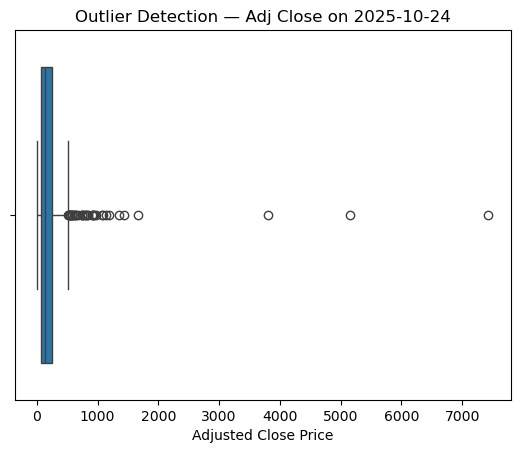

In [ ]:
# select Oct24,2025 to examine the outliers in that day.
Oct24_df = stock_df[stock_df['Date'] == 'Oct 24, 2025']
sns.boxplot(x="Adj Close", data=Oct24_df)
plt.xlabel("Adjusted Close Price")
plt.title("Outlier Detection — Adj Close on 2025-10-24")
plt.show()


**Observation 11**
- The boxplot above visualizes the distribution of Adjusted Close Price on October 24, 2025.
- Most of the data points are clustered between 0 and 500, indicating that the majority of stocks trade at relatively low prices.
- Several extreme outliers are observed beyond 1,000 and even above 7,000, which represent high-priced stocks.
- The large spread between the lower whisker and the extreme outliers suggests a right-skewed distribution of stock prices.

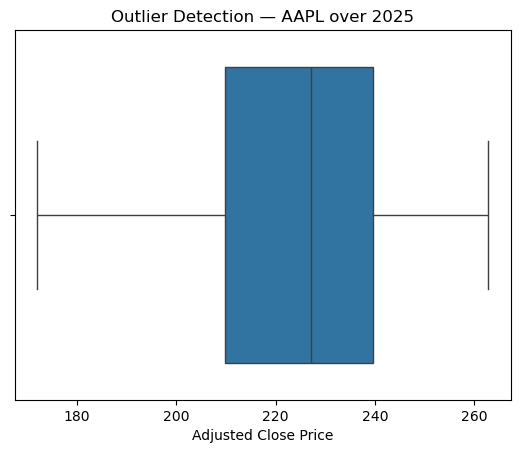

In [ ]:
# select 'AAPL' company, to see its outliers of adj close price in the past one year.
AAPL_df = stock_df[stock_df['Ticker'] == 'AAPL']
sns.boxplot(x="Adj Close", data=AAPL_df)
plt.xlabel("Adjusted Close Price")
plt.title("Outlier Detection — AAPL over 2025")
plt.show()

**Observation 12**
- The boxplot above represents the distribution of Apple’s (AAPL) Adjusted Close Price throughout the year 2025.
- The price range is approximately from 175 to 260 USD, showing moderate daily variation.
- The median is around 220 USD, and the distribution appears symmetric with no visible outliers, indicating stable stock performance during this period.

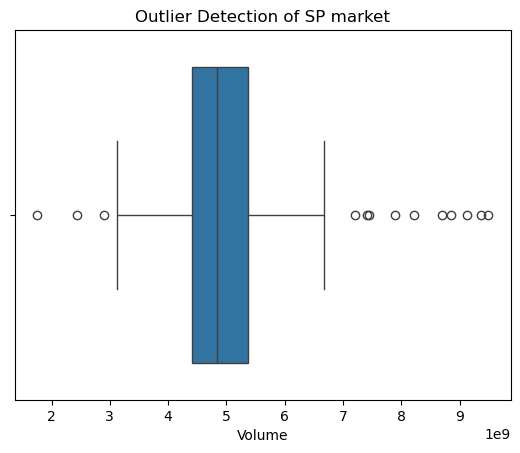

In [ ]:
# check the market volume outliers
sns.boxplot(x="Volume", data=market_df)
plt.xlabel("Volume")
plt.title("Outlier Detection of SP market")
plt.show()

**Observation 13**
- The boxplot above represents the distribution of the S&P 500 market’s daily trading volume during the selected period.
- The central volume range lies roughly between 4.0×10⁹ and 6.0×10⁹ shares, indicating consistent, moderate trading activity on most days.
- Only a few low-volume points appear on the left, while several high-volume outliers are visible on the right, reflecting occasional spikes in market participation.
- Overall, the distribution is right-skewed, suggesting that unusually high trading volumes occur more frequently than unusually low ones.

## B. Univariate, Bivariate, and Multivariate Analyses

### 1. Data wrangling

**i. Cleaning data**

In [ ]:
# drop duplicates, though there are not.
df = df.drop_duplicates()

In [ ]:
# transfer 'Date' from object to datetime type.
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [ ]:
# select the first four digits to be the founded year.
# because some 'founded' is like 2009(1998)
df['Founded'] = df['Founded'].astype(str).str.extract(r'(\d{4})')[0]

In [ ]:
# transfer 'Founded' from object to numerical.
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce').astype('Int64')

In [ ]:
# the dates for each ticker are sorted in descending order, we need to sort them in ascending order to correctly calculate the daily returns
df = df.sort_values(['Ticker', 'Date'], ascending=[True, True]).reset_index(drop=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       126000 non-null  datetime64[ns]
 1   Ticker     126000 non-null  object        
 2   Company    126000 non-null  object        
 3   Sector     126000 non-null  object        
 4   Founded    126000 non-null  Int64         
 5   Open       126000 non-null  float64       
 6   High       126000 non-null  float64       
 7   Low        126000 non-null  float64       
 8   Close      126000 non-null  float64       
 9   Adj Close  126000 non-null  float64       
 10  Volume     126000 non-null  int64         
dtypes: Int64(1), datetime64[ns](1), float64(5), int64(1), object(3)
memory usage: 10.7+ MB


**Observation 13**
- After cleaning, the dataset contains 126000 records and 11 columns, with no missing values in any field.
- The Date column has been successfully converted from object to datetime64, allowing for proper time-series analysis.
- The Founded column, originally stored as a mixed string (e.g., “2009(1998)”), was cleaned to extract the first four digits and converted to integer (Int64) type.
- The dataset is now properly structured, clean, and ready for further EDA.

**ii. Handling missing values**

In [ ]:
df.dropna(inplace=True)

**iii. Transforming the variables, if needed**

In [ ]:
df['Year'] = pd.to_datetime(df['Date']).dt.year

In [ ]:
df['Month'] = pd.to_datetime(df['Date']).dt.month

In [ ]:
df['Day'] = pd.to_datetime(df['Date']).dt.day

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       126000 non-null  datetime64[ns]
 1   Ticker     126000 non-null  object        
 2   Company    126000 non-null  object        
 3   Sector     126000 non-null  object        
 4   Founded    126000 non-null  Int64         
 5   Open       126000 non-null  float64       
 6   High       126000 non-null  float64       
 7   Low        126000 non-null  float64       
 8   Close      126000 non-null  float64       
 9   Adj Close  126000 non-null  float64       
 10  Volume     126000 non-null  int64         
 11  Year       126000 non-null  int32         
 12  Month      126000 non-null  int32         
 13  Day        126000 non-null  int32         
dtypes: Int64(1), datetime64[ns](1), float64(5), int32(3), int64(1), object(3)
memory usage: 12.1+ MB


**Observation 14**
- Three new time-based columns — Year, Month, and Day — were successfully extracted from the Date column.
- The total number of columns increased from 11 to 14, enriching the dataset with more granular time information.
- These transformations enable time-series analysis, such as identifying seasonal patterns, monthly trends, or yearly stock performance comparisons.

**iv. Engineering new variables, if needed**

In [ ]:
current_year = 2025
df['Age'] = current_year - df['Founded']

In [ ]:
# create daily return features
df['Return'] = df.groupby('Ticker')['Adj Close'].pct_change()

In [ ]:
# check if all the stocks are correct, because the first 'Return' of each stock should be NaN
df.groupby('Ticker').head(1)['Return'].isna().sum()

np.int64(504)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       126000 non-null  datetime64[ns]
 1   Ticker     126000 non-null  object        
 2   Company    126000 non-null  object        
 3   Sector     126000 non-null  object        
 4   Founded    126000 non-null  Int64         
 5   Open       126000 non-null  float64       
 6   High       126000 non-null  float64       
 7   Low        126000 non-null  float64       
 8   Close      126000 non-null  float64       
 9   Adj Close  126000 non-null  float64       
 10  Volume     126000 non-null  int64         
 11  Year       126000 non-null  int32         
 12  Month      126000 non-null  int32         
 13  Day        126000 non-null  int32         
 14  Age        126000 non-null  Int64         
 15  Return     125496 non-null  float64       
dtypes: Int64(2), datetim

**Observation 15**
- A new variable Age was created to represent the number of years since each company was founded, calculated as 2025 - Founded.
- A new variable Return was created to measure the daily percentage change in each stock’s Adjusted Close price.
- The dataset contains 16 columns and 126000 records, with all fields fully populated except the Return column, which has expected NaN values for the first day of each ticker. All data types are correctly assigned, confirming that the dataset is clean and ready for analysis.

**v. Handling outliers**

In [ ]:
stock_df = df[df['Ticker'] != 'S&P500']
market_df = df[df['Ticker'] == 'S&P500']

In [ ]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    outliers = df[(df[column] > upper) | (df[column] < lower)]
    # check the outliers number
    print(f"Number of outliers in [{column}]:", outliers.shape[0])
    # check the highest outliers information
    print(f"\nHighest value in [{column}]: {df[column].max()}")
    print("\nRow with highest value:")
    print(df.loc[df[column].idxmax()])

In [ ]:
# see the outliers of adj close on '2025-10-24'.
Oct24_df = stock_df[stock_df['Date'] == 'Oct 24, 2025']
detect_outliers(Oct24_df,'Adj Close')

Number of outliers in [Adj Close]: 39

Highest value in [Adj Close]: 7430.92

Row with highest value:
Date            2025-10-24 00:00:00
Ticker                          NVR
Company                   NVR, Inc.
Sector       Consumer Discretionary
Founded                        1980
Open                         7718.0
High                         7718.0
Low                         7425.44
Close                       7430.92
Adj Close                   7430.92
Volume                        22000
Year                           2025
Month                            10
Day                              24
Age                              45
Return                    -0.032358
Name: 86249, dtype: object


In [ ]:
# see the outliers of return on '2025-10-24'.
detect_outliers(Oct24_df,'Return')

Number of outliers in [Return]: 31

Highest value in [Return]: 0.12155591572123181

Row with highest value:
Date            2025-10-24 00:00:00
Ticker                            F
Company          Ford Motor Company
Sector       Consumer Discretionary
Founded                        1903
Open                          12.73
High                          13.97
Low                           12.71
Close                         13.84
Adj Close                     13.84
Volume                    298283900
Year                           2025
Month                            10
Day                              24
Age                             122
Return                     0.121556
Name: 44749, dtype: object


**Observation 16**
- Using the IQR method, a total of 39 outliers were detected in the Adj Close prices on October 24, 2025.
- The highest adjusted close price was $7,430.92, belonging to the company NVR, Inc. (Ticker: NVR), which operates in the Consumer Discretionary sector.
- However, this outlier is valid, as NVR is known for maintaining a very high share price in real markets rather than a data error.
- Also, Ford Motor Company had the highest daily return on 2025-10-24, which is + 12.16%
- We don't plan to drop all these outliers in stock market dataset, because these data are valid.

### 2. Univariate Analysis

In [ ]:
# split two df
stock_df = df[df['Ticker'] != 'S&P500']
market_df = df[df['Ticker'] == 'S&P500']

In [ ]:
market_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 100750 to 100999
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       250 non-null    datetime64[ns]
 1   Ticker     250 non-null    object        
 2   Company    250 non-null    object        
 3   Sector     250 non-null    object        
 4   Founded    250 non-null    Int64         
 5   Open       250 non-null    float64       
 6   High       250 non-null    float64       
 7   Low        250 non-null    float64       
 8   Close      250 non-null    float64       
 9   Adj Close  250 non-null    float64       
 10  Volume     250 non-null    int64         
 11  Year       250 non-null    int32         
 12  Month      250 non-null    int32         
 13  Day        250 non-null    int32         
 14  Age        250 non-null    Int64         
 15  Return     249 non-null    float64       
dtypes: Int64(2), datetime64[ns](1), float64(6

In [ ]:
market_df.head()

,Date,Ticker,Company,Sector,Founded,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Age,Return
100750,2024-10-25,S&P500,S&P 500 Overall Market,Market,1957,5826.75,5862.82,5799.98,5808.12,5808.12,3501280000,2024,10,25,68,NaN
100751,2024-10-28,S&P500,S&P 500 Overall Market,Market,1957,5833.93,5842.92,5823.08,5823.52,5823.52,3691280000,2024,10,28,68,0.002651
100752,2024-10-29,S&P500,S&P 500 Overall Market,Market,1957,5819.68,5847.19,5802.17,5832.92,5832.92,3879100000,2024,10,29,68,0.001614
100753,2024-10-30,S&P500,S&P 500 Overall Market,Market,1957,5832.65,5850.94,5811.28,5813.67,5813.67,3851120000,2024,10,30,68,-0.003300
100754,2024-10-31,S&P500,S&P 500 Overall Market,Market,1957,5775.34,5775.34,5702.86,5705.45,5705.45,4425660000,2024,10,31,68,-0.018615


**Observations:**
- The new market_df dataset gives us an overall picture of how the S&P 500 market behaves, rather than focusing on individual companies.
- Each row now represents a single trading day, showing the weighted prices and trading volumes across all 503 stocks.
- This makes it easier to study overall market movements, identify periods of high or low activity, and explore relationships between key market indicators like open, close, high, and low prices.

**i. Outliers**

**Detect outliers using boxplots**

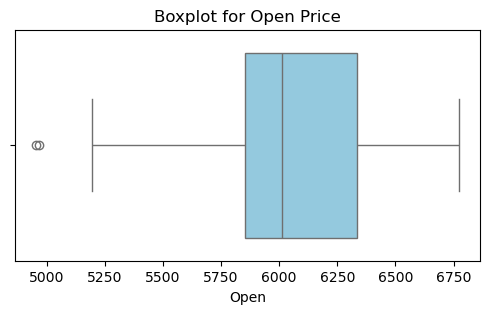

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=market_df['Open'], color='skyblue')
plt.title('Boxplot for Open Price')
plt.xlabel('Open')
plt.show()

**Observation:**  
- The Open price boxplot shows a few noticeable lower outliers, indicating days when the market opened significantly lower than the typical range.
- These lower openings may reflect early reactions to negative overnight news, weak investor sentiment, or pre-market volatility.
- The rest of the values fall within a stable range, suggesting generally consistent opening prices across the period.

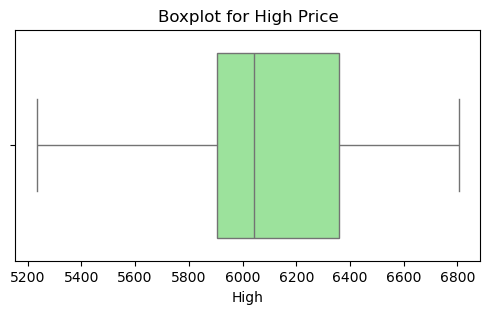

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=market_df['High'], color='lightgreen')
plt.title('Boxplot for High Price')
plt.xlabel('High')
plt.show()

**Observation:**  
- The boxplot for the High price shows no visible outliers, indicating stable intraday highs throughout the observed period.
- All values fall within the whiskers, suggesting that the market did not experience extreme upward spikes in high prices.
- This stability indicates that intraday highs remained within a consistent range with no unusually high or low peaks.

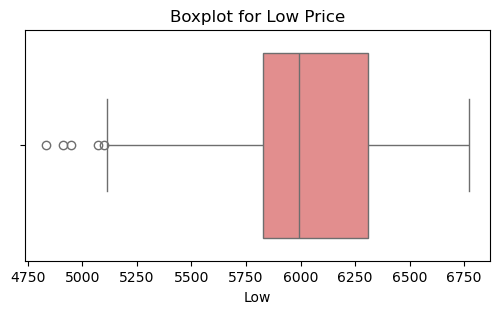

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=market_df['Low'], color='lightcoral')
plt.title('Boxplot for Low Price')
plt.xlabel('Low')
plt.show()

**Observation:**  
- The Low price boxplot shows a small number of lower outliers, meaning there were a few days when the market dipped more than usual.
- Aside from those rare dips, the daily low prices stayed within a steady range, suggesting that the market didn’t experience many sharp or unexpected drops.

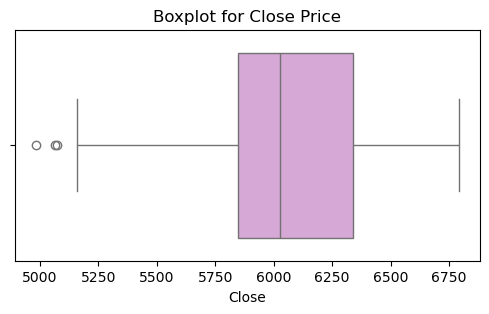

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=market_df['Close'], color='plum')
plt.title('Boxplot for Close Price')
plt.xlabel('Close')
plt.show()

**Observation:**  
- The Close price boxplot reveals a few mild lower outliers, showing that on some days the market ended noticeably weaker than normal.
- These could represent late-day sell-offs or negative news that influenced investors toward the end of the session.
- Most closing prices, however, clustered in a stable range, pointing to consistent day-end market behavior.

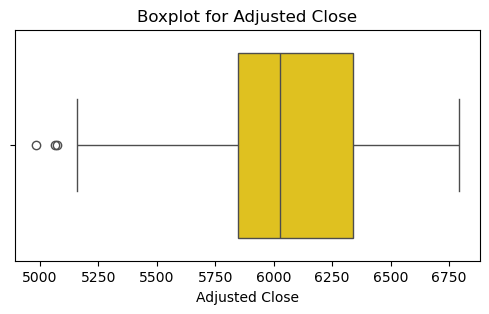

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=market_df['Adj Close'], color='gold')
plt.title('Boxplot for Adjusted Close')
plt.xlabel('Adjusted Close')
plt.show()

**Observation:**  
The Adjusted Close prices follow a similar pattern to the Close prices, with slight lower outliers.
These outliers can be linked to market adjustments such as dividends or stock splits, which slightly modify closing prices over time.

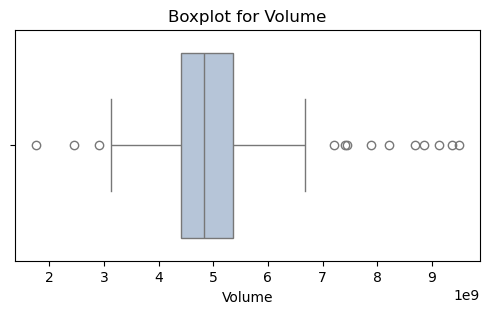

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=market_df['Volume'], color='lightsteelblue')
plt.title('Boxplot for Volume')
plt.xlabel('Volume')
plt.show()

**Observation:**  
- The boxplot shows several outliers on both sides, but the right side has more, indicating that some days had much higher trading volume than normal.
- The central box is fairly narrow, which means that most trading days cluster around a consistent volume range.
- The left side has only a few low-volume outliers, suggesting that there were very few days when the trading volume was much lower than normal.

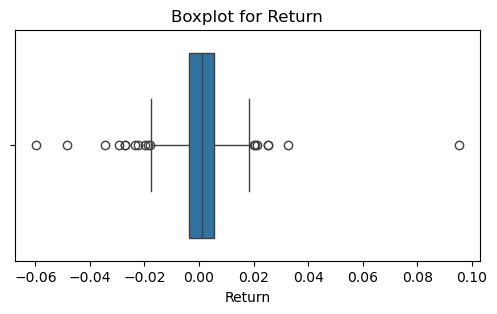

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=market_df['Return'])
plt.title('Boxplot for Return')
plt.xlabel('Return')
plt.show()

**Observation:**  
- The Return boxplot shows a narrow interquartile range centered around zero, indicating that most aggregated daily returns of the S&P 503 stocks cluster near the mean, reflecting the overall market’s stable day-to-day performance.  
- A few outliers appear on both tails, especially on the positive side, which represent trading days when the combined market return was unusually high or low.

**ii. Data Distribution**

In [ ]:
num_cols = ['Open', 'Close', 'High', 'Low', 'Adj Close','Volume','Return']

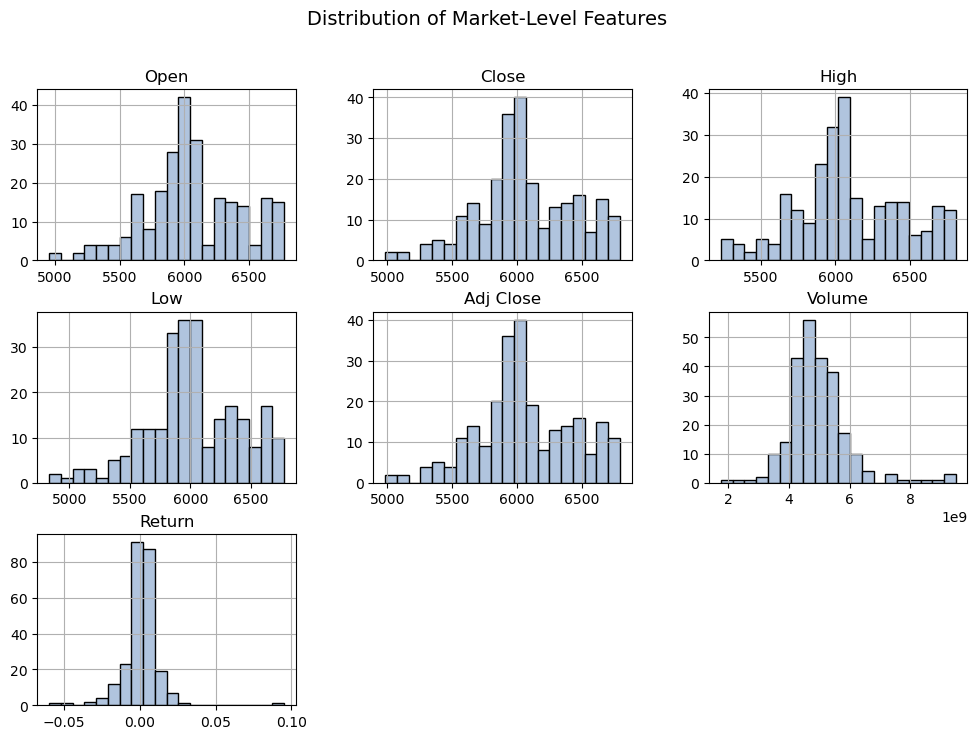

In [ ]:
# Visualize data distribution using histograms and KDE plots
market_df[num_cols].hist(figsize=(12, 8), bins=20, color='lightsteelblue', edgecolor='black')
plt.suptitle("Distribution of Market-Level Features", fontsize=14)
plt.show()

**Observation:**
- The price features (Open, High, Low, Close, and Adj Close) all cluster tightly around their central ranges, with slight right-skewness indicating a few higher-than-normal price days.
- Volume, however, is much more right-skewed, indicating that while most days have normal trading activity, a handful of days experience exceptionally high trading.
- The return values are concentrated around zero, showing that daily market changes are usually mild, with only occasional sharp jumps or drops.

**iii. Skewness**

In [ ]:
# Calculate skewness
skew_values = market_df[num_cols].skew().sort_values(ascending=False)
print("Skewness of each variable:\n", skew_values)

Skewness of each variable:
 Volume       1.481194
Return       1.003287
High         0.051441
Adj Close   -0.098097
Close       -0.098097
Open        -0.106948
Low         -0.243518
dtype: float64


**Observations:**  
- The Volume variable shows a high positive skew (1.48), indicating occasional days of unusually high trading activity. The Return variable has a moderate positive skew (1.003), suggesting that there are a few days with noticeably higher positive returns.
- In contrast, price-related variables (Open, High, Low, Close, Adj Close) have negative skewness (-0.1 to -2.4), meaning prices are mostly high with few sharp declines. This suggests stable market performance with rare periods of heavy trading and sudden price drops.

### 3. Bivariate Analysis

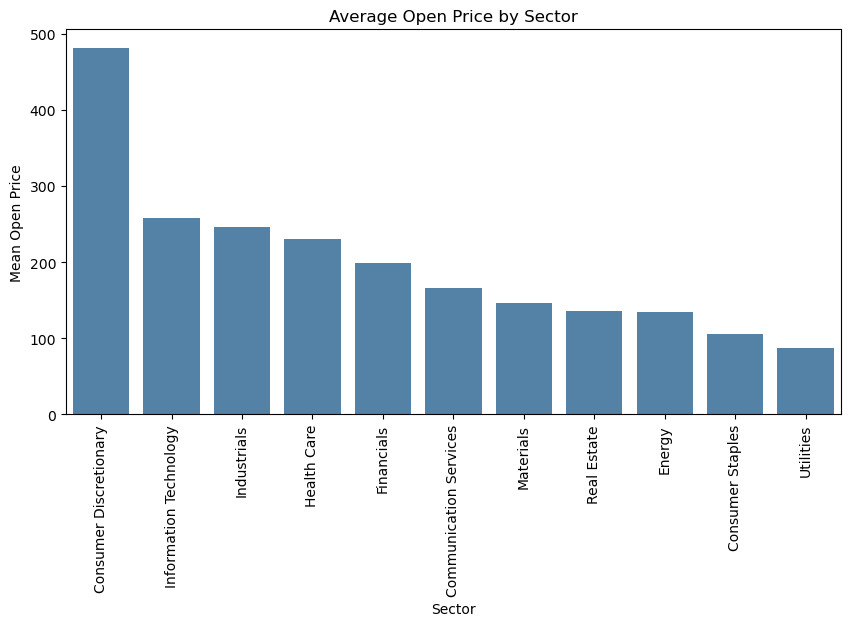

In [ ]:
# Sector-based comparison
sector_df = stock_df.groupby('Sector')[['Open']].mean().sort_values('Open', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=sector_df.index, y=sector_df['Open'], color='steelblue')
plt.xticks(rotation= 90)
plt.title("Average Open Price by Sector")
plt.ylabel("Mean Open Price")
plt.show()

**Observation:** The barplot reveals sector-level differences:
- The barplot shows that Consumer Discretionary has the highest average open price, meaning companies in this sector tend to trade at higher values.
- Information Technology , Industrials, and Health Care follow behind, showing strong market valuations and steady investor demand.
- On the lower end, sectors like Utilities, Consumer Staples, and Energy have the lowest average opening prices, which fits their reputation as slower-growth, stable industries.

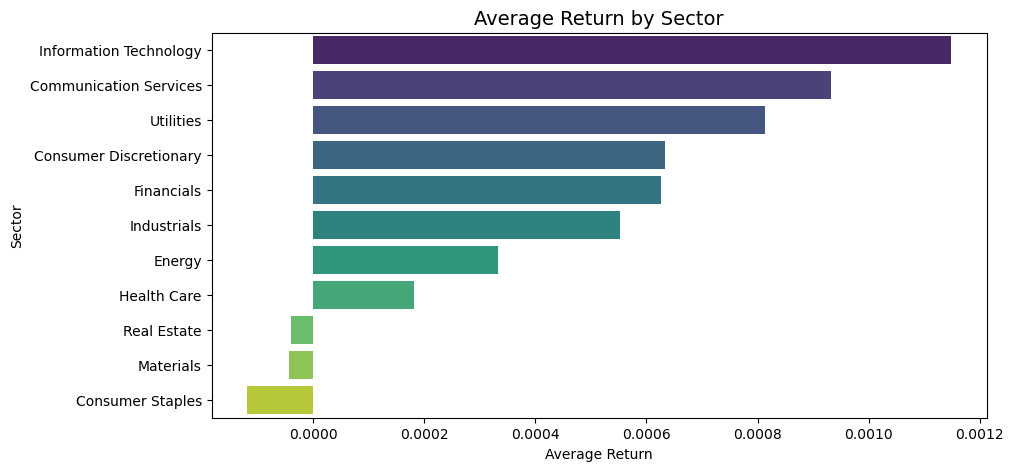

In [ ]:
# Calculate average return by sector
avg_return_sector = stock_df.groupby('Sector')['Return'].mean().reset_index().sort_values(by='Return', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot( x='Return', y='Sector', data=avg_return_sector, hue='Sector', palette='viridis', legend=False )
plt.title("Average Return by Sector", fontsize=14)
plt.xlabel("Average Return")
plt.ylabel("Sector")
plt.show()

**Observation:**
- Information Technology and Communication Services sectors have the highest average returns, indicating strong growth and consistent investor confidence.
- Utilities and Consumer Discretionary sectors performed relatively well, reflecting stability and responsiveness to market demand.
- Sectors like Consumer Staples, Materials, and Real Estate have much lower average returns, indicating slower growth and more conservative market behavior.
- These lower-return sectors tend to be less volatile and provide steady returns, especially during uncertain market conditions.

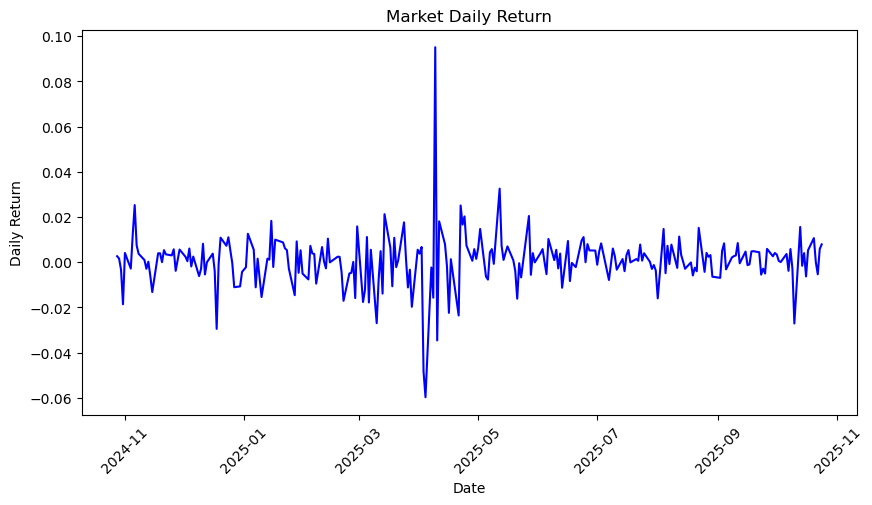

In [ ]:
# Date and Return
plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='Return', data=market_df, color='blue')
plt.xticks(rotation=45)
plt.title("Market Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

**Observation:**
- The average daily returns fluctuate around zero, indicating that the market generally remains stable with small day-to-day variations.
- A few sharp spikes and dips highlight high-volatility periods, likely triggered by major market or economic events.
- The largest positive and negative swings (around +0.09 and –0.05) indicate rare but strong market-wide reactions.
- Overall, the market appears steady with occasional bursts of sudden movement.

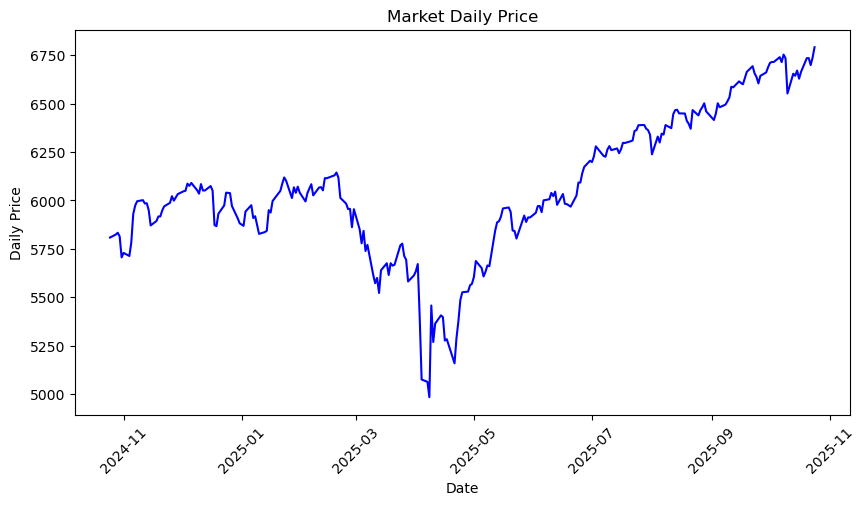

In [ ]:
# Date and Adjusted Close Price
plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='Adj Close', data=market_df, color='blue')
plt.xticks(rotation=45)
plt.title("Market Daily Price")
plt.xlabel("Date")
plt.ylabel("Daily Price")
plt.show()

**Observation:**
- The line plot shows that the adjusted close price mostly increases over time, indicating steady market growth.
- It also shows a sharp drop around March–April 2025, suggesting a short period of market decline.
- After this dip, the line rises again, showing that the market recovered quickly and continued to grow.

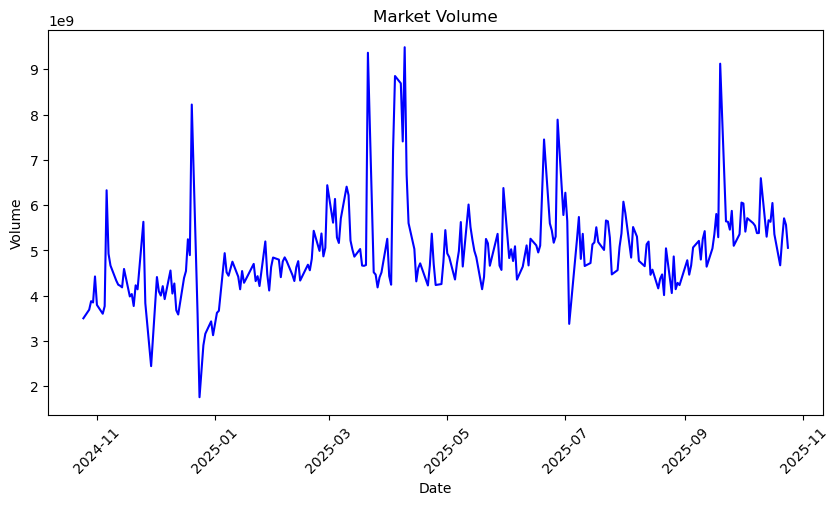

In [ ]:
# Date and Adjusted Close Price
plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='Volume', data=market_df, color='blue')
plt.xticks(rotation=45)
plt.title("Market Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

**Observation:**
- The market trading volume fluctuated significantly throughout the year, with several sharp spikes indicating periods of heightened trading activity — possibly around major earnings announcements or economic events.
- Despite short-term drops, overall volume remained stable, suggesting consistent investor engagement across the S&P 500.

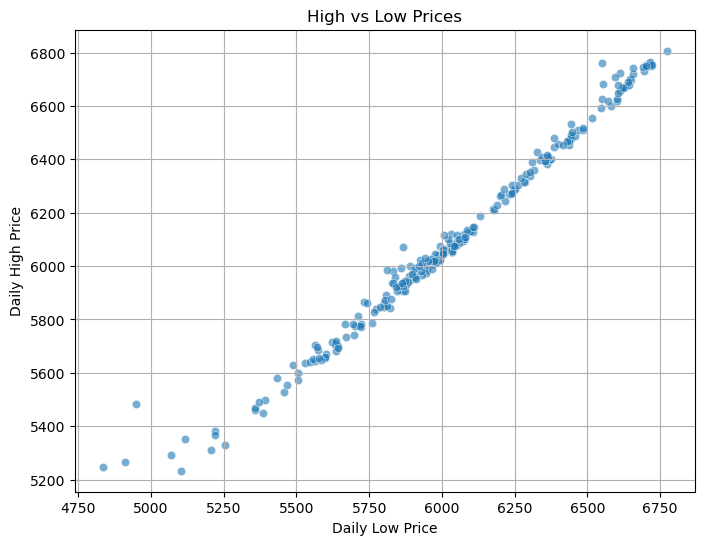

Correlation between High and Low prices: 0.99


In [ ]:
# Scatterplot between High and Low prices
plt.figure(figsize=(8,6))
sns.scatterplot(x='Low', y='High', data=market_df, alpha=0.6)
plt.title('High vs Low Prices')
plt.xlabel('Daily Low Price')
plt.ylabel('Daily High Price')
plt.grid(True)
plt.show()

# Optional: Calculate correlation
correlation = market_df['High'].corr(market_df['Low'])
print(f"Correlation between High and Low prices: {correlation:.2f}")

**Observation:**
- The scatterplot shows a strong positive relationship between daily high and low prices when the low price is higher, the high price is also higher.
- The points follow a straight upward pattern, meaning the two values move together very consistently.
- This indicates normal and predictable intraday market behavior, with no unusual jumps or drops between highs and lows.

### 4. Multivariate Analysis

**i. correlation**

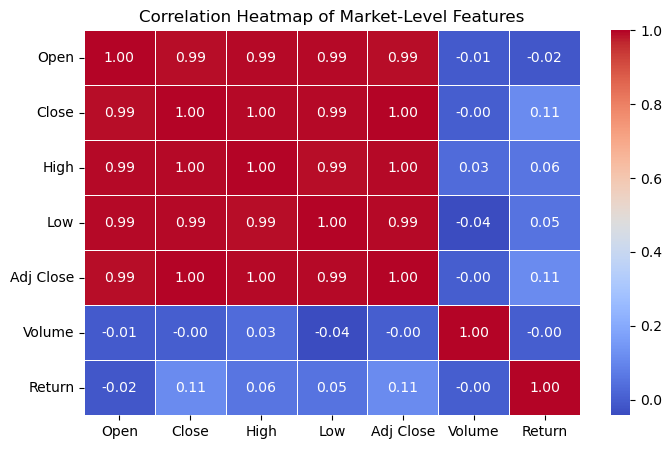

In [ ]:
# Correlation heatmap
corr = market_df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Market-Level Features")
plt.show()

**Observation:**
- The price features (Open, High, Low, Close, and Adj Close) all have very strong positive correlations, meaning they move together almost perfectly during the trading day.
- Volume shows almost no correlation with the price variables, suggesting that higher trading activity does not always mean higher or lower prices.
- Return has only weak correlations with other features, which is expected because daily returns fluctuate independently of price levels.

## C.  EDA Summary

1. The dataset contains 126,000 records and 11 columns, providing daily stock information for multiple S&P 500 companies. All columns were cleaned and standardized, resulting in no missing values.
2. Examining the outliers shows that some stocks had very high adjusted close prices on 2025-10-24, while Apple’s prices stayed normal with no outliers. The S&P 500 trading volume also had a few very high spikes, meaning some days had much heavier trading than usual.
3. New variables such as Year, Month, Day, Age and Daily Return were engineered, enhancing the dataset’s analytical depth.
4. The Date column was converted to a datetime type, enabling accurate time-series analysis.The Founded column was cleaned to extract the four-digit founding year and converted to integer (Int64) format.
5. The price variables (Open, High, Low, Close, Adj Close) generally move together and fall within similar ranges, showing stable and consistent market pricing.
6. Open, Low, and Close prices show a few lower-end outliers, reflecting occasional weak trading days, while Adjusted Close has additional minor outliers caused by routine adjustments like dividends or stock splits.
7. Volume shows the strongest outlier behavior, with several high-volume spikes and a few low-volume days, indicating periods of unusually heavy or unusually quiet trading activity.Daily returns are mostly centered around zero, with only a few sharp positive or negative spikes, showing that the market typically moves in small increments but occasionally experiences bursts of volatility.
8. Distribution: The price variables (Open, High, Low, Close, Adj Close) are tightly clustered within similar ranges, while Volume and Return show wider spread, indicating that most days follow normal trading behavior with only a few days showing unusually high activity or movement.
9. Skewness: Price variables have mild right skewness, showing stable price behavior, whereas Volume and Return are strongly right-skewed, meaning the market occasionally experiences very high trading volumes or unusually strong positive returns.
10. Sector-level price comparison reveals clear differences, with sectors like Consumer Discretionary and Information Technology having higher average Open prices, while sectors like Utilities and Consumer Staples trade at lower price ranges.
11. Sector-wise returns show that Technology and Communication Services are the top performers, while sectors such as Materials, Real Estate, and Consumer Staples generate lower but steady returns, reflecting differences in market sensitivity and growth potential.
12. The time-series of daily returns shows that the market stays stable around zero most of the year, with only a few sudden spikes indicating brief periods of volatility.
13. The time-trend of Adjusted Close prices shows overall upward market momentum, with one noticeable dip around March–April 2025, followed by a strong recovery, indicating temporary volatility within a long-term growth pattern.
14. The correlation heatmap shows that all price variables (Open, High, Low, Close, Adj Close) move almost identically, while Volume and Return have very weak correlations with other features, reflecting independent trading activity and daily price fluctuations.
15. The overall EDA shows a highly consistent and well-structured market dataset, where pricing variables are strongly aligned, sector patterns are clearly distinguishable, and time-series trends reveal stable long-term growth with short periods of volatility, making the dataset reliable and fully ready for deeper modeling and forecasting.

# 6. Data Visualization

In [ ]:
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Trading Range'] = df['High'] - df['Low']

In [ ]:
# Group by Ticker to calculate daily return and volatility correctly for each stock
df['Daily Return (%)'] = df.groupby('Ticker')['Adj Close'].pct_change() * 100
df['Volatility (%)'] = df.groupby('Ticker')['Daily Return (%)'].rolling(20).std().reset_index(level=0, drop=True)
df['Log_Volume'] = np.log(df['Volume'] + 1)
df['Bullish Day'] = np.where(df['Close'] > df['Open'], 'Bullish', 'Bearish')

In [ ]:
stock_df = df[df['Ticker'] != 'S&P500']
market_df = df[df['Ticker'] == 'S&P500']

In [ ]:
# select the top trading volume stock
top5_tickers_by_volume = stock_df.groupby('Ticker')['Volume'].sum().nlargest(5).index.tolist()

In [ ]:
print("--- Data Processing Summary ---")
print(f"Top 5 Tickers by Total Trading Volume (excluding S&P500): {top5_tickers_by_volume}")

--- Data Processing Summary ---
Top 5 Tickers by Total Trading Volume (excluding S&P500): ['NVDA', 'TSLA', 'INTC', 'F', 'PLTR']


## 6.1 Univariate

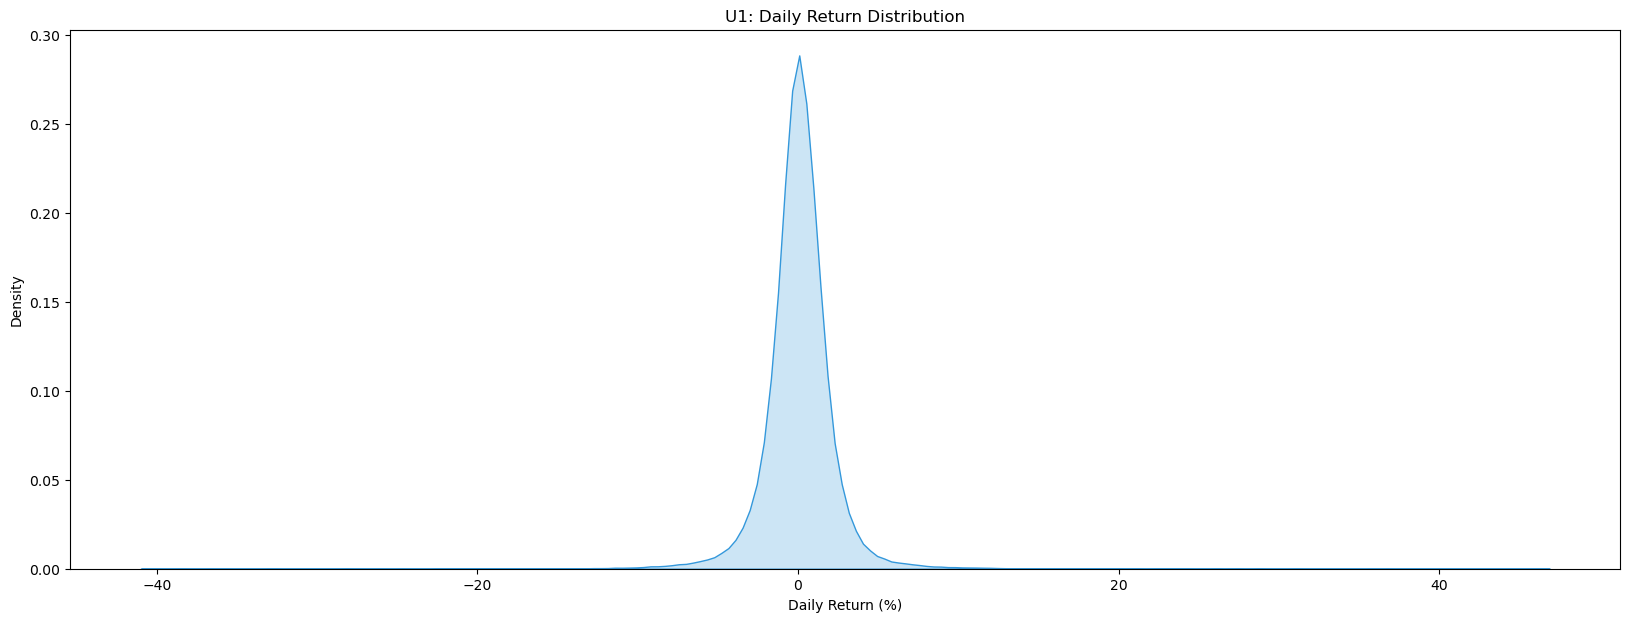

In [ ]:
# --- U1: Daily Return Distribution ---
plt.figure(figsize=(20,7))
sns.kdeplot(stock_df['Daily Return (%)'], fill=True, color='#3498db')
plt.title("U1: Daily Return Distribution")
plt.show()


**Observation**
- Kernel Density Estimate of Daily Returns  
- A density curve centered near zero, with a distinct fat-tailed peak.  
- The distribution of daily returns is fat-tailed and not normally distributed. This indicates a higher likelihood of extreme positive or negative return events across stocks in sectors such as Technology, Financials, and Healthcare.


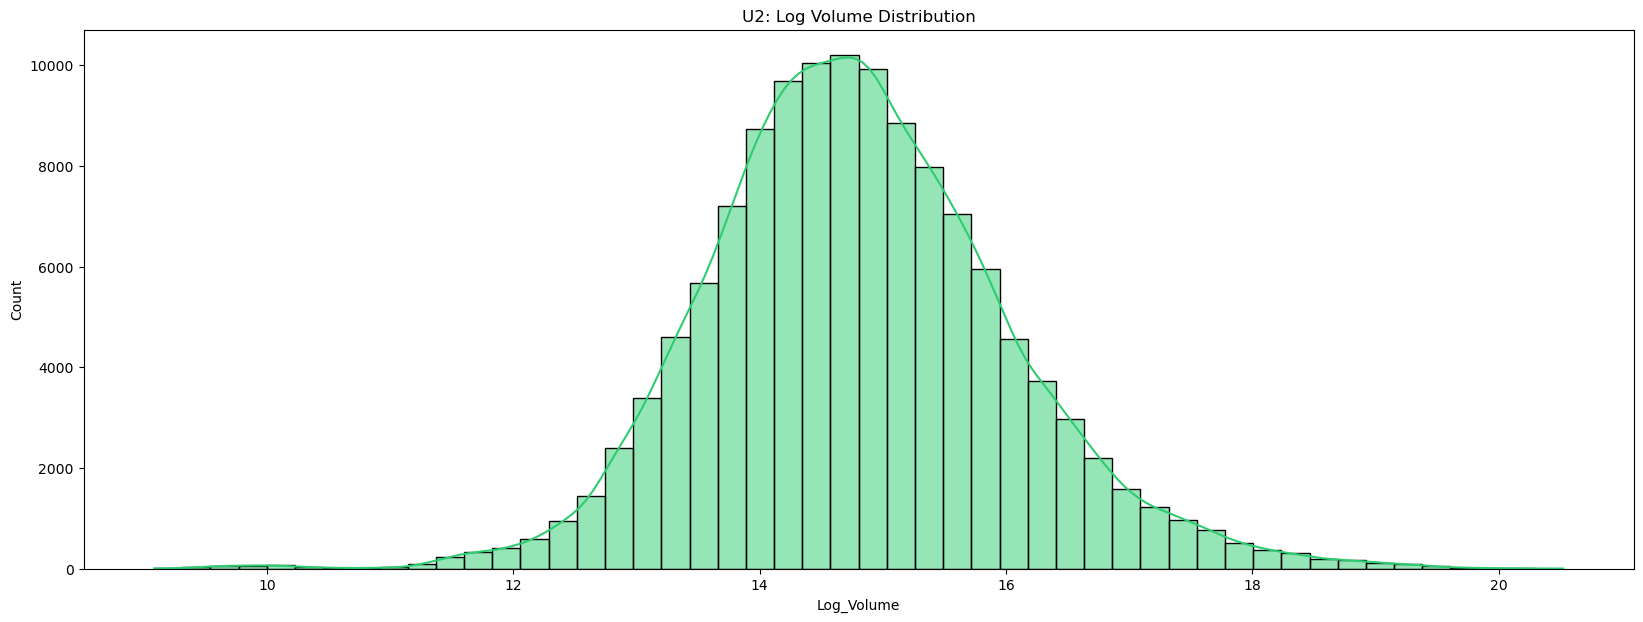

In [ ]:
# --- U2: Log Volume Distribution ---
plt.figure(figsize=(20,7))
sns.histplot(stock_df['Log_Volume'], kde=True, bins=50, color='#2ecc71')
plt.title("U2: Log Volume Distribution")
plt.show()


**Observation**
- A histogram of log-transformed trading volume shows a right-skewed distribution, even after the log transformation.
- The histogram has a long tail extending toward high-volume days, indicating occasional spikes in trading activity.
- Trading volume is right-skewed. While most stocks (particularly from Industrials, Financials, and Consumer Staples) trade at moderate volumes, certain companies especially large cap Technology and Communication firms exhibit extreme volume spikes driven by news or earnings events.


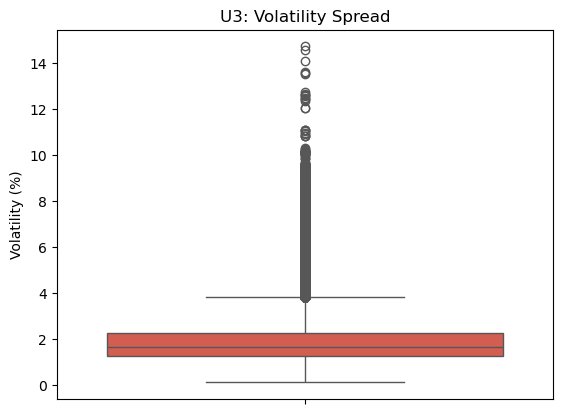

In [ ]:
# --- U3: Volatility Spread ---
sns.boxplot(y= stock_df['Volatility (%)'], color='#e74c3c')
plt.title("U3: Volatility Spread")
plt.show()

**Observation**
- A box-and-whisker plot of daily volatility shows a tight median with a narrow interquartile range.
- Numerous outliers appear above the upper whisker, indicating occasional extreme volatility days.
- The market generally operates within a narrow band of daily price movements, but sporadic high-volatility events (e.g., policy announcements, macro shocks) dominate the risk profile.
- Daily volatility shows long upper whiskers, meaning several stocks—particularly in Technology, Communication Services, and Energy—experience sudden volatility surges due to macroeconomic shocks or unexpected market events.

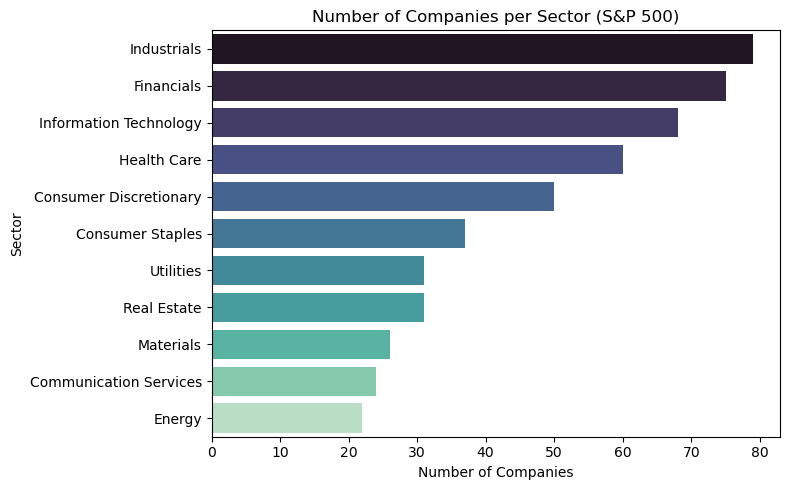

In [ ]:
# --- U4: Sector Observation Count ---
sector_count = stock_df[['Ticker', 'Sector']].drop_duplicates()['Sector'].value_counts().reset_index()
sector_count.columns = ['Sector', 'CompanyCount']

plt.figure(figsize=(8,5))
sns.barplot(y='Sector', x='CompanyCount', data=sector_count, palette='mako')
plt.title("Number of Companies per Sector (S&P 500)")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

**Observation**
- A horizontal bar plot shows the count of observations per sector.
- Industrial and Financials (or other large sectors) have the highest observation counts.
- This indicates a sampling bias toward the largest sectors, meaning overall analysis may be disproportionately influenced by these market segments.

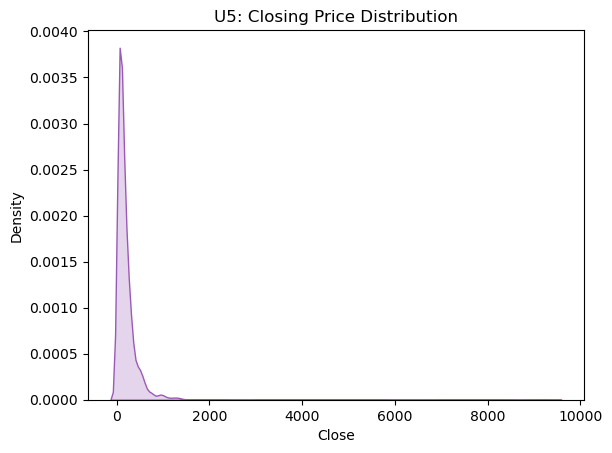

In [ ]:
# --- U5: Closing Price Distribution ---
sns.kdeplot(stock_df['Close'], fill=True, color='#9b59b6')
plt.title("U5: Closing Price Distribution")
plt.show()

**Observation**
- A KDE plot shows the distribution of closing prices across stocks.
- Closing prices cluster at different levels across companies. High priced stocks like those in Technology and Consumer Discretionary contrast with lower priced firms in Utilities and Real Estate, showing that raw prices differ structurally and require normalization before comparison.

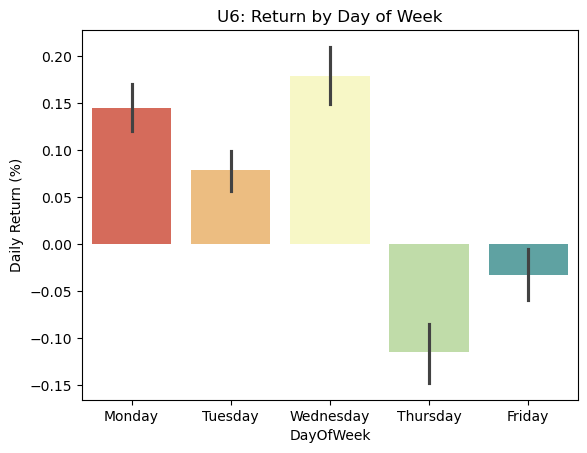

In [ ]:
# --- U6: Return by Day of Week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sns.barplot(x='DayOfWeek', y='Daily Return (%)', data=stock_df, order=day_order, palette='Spectral')
plt.title("U6: Return by Day of Week")
plt.show()

**Observation**
- A bar plot displays the mean daily return for each day of the week.
- The plot shows a clear mid week strength pattern. Wednesday records the highest average return, followed by Monday, both showing positive gains. Tuesday also shows a small positive return but noticeably lower than Monday and Wednesday. In contrast, Thursday exhibits the most negative average return, indicating mid week profit taking or selling pressure. Friday shows a mild negative return, suggesting a slight pullback as investors reduce risk ahead of the weekend. Overall, the returns suggest stronger performance early to mid week and weaker sentiment toward the end of the trading week.

In [ ]:
# --- U7: Pie chart of sector distribution ---
sector_counts = stock_df['Sector'].value_counts()
explode = [0.05 if i == sector_counts.idxmax() else 0 for i in sector_counts.index]
colors = sns.color_palette('tab20', len(sector_counts))

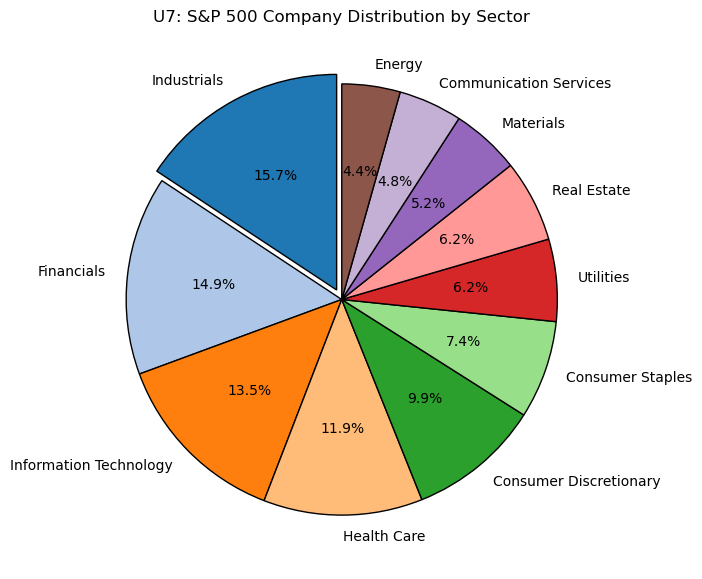

In [ ]:
plt.figure(figsize=(20,7))
plt.pie(sector_counts.values, labels=sector_counts.index, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode, wedgeprops={'edgecolor': 'black', 'linewidth': 1});
plt.title("U7: S&P 500 Company Distribution by Sector");
plt.show()

**Observation**
- A pie chart shows the distribution of the 11 GICS sectors in the S&P 500.
- The largest slices typically belong to Financials, Information Technology, and Healthcare, with percentages displayed.
- This highlights concentration risk: the index’s performance is disproportionately influenced by these key sectors, emphasizing the need to analyze their fundamentals for accurate market assessment.

In [ ]:
# --- U8: Bar plot about daily volatility by sector ---
stock_df['Daily Volatility'] = ((stock_df['High'] - stock_df['Low']) / stock_df['Close']) * 100

In [ ]:
# calculate avg volatility for each sector
avg_volatility_per_sector = stock_df.groupby('Sector')['Daily Volatility'].mean().sort_values(ascending=False)

In [ ]:
# define color
light_colors = ['#aec7e8', '#98df8a', '#ffbb78', '#ff9896', '#c5b0d5', '#c49c94']
palette = [light_colors[i % len(light_colors)] for i in range(len(avg_volatility_per_sector))]

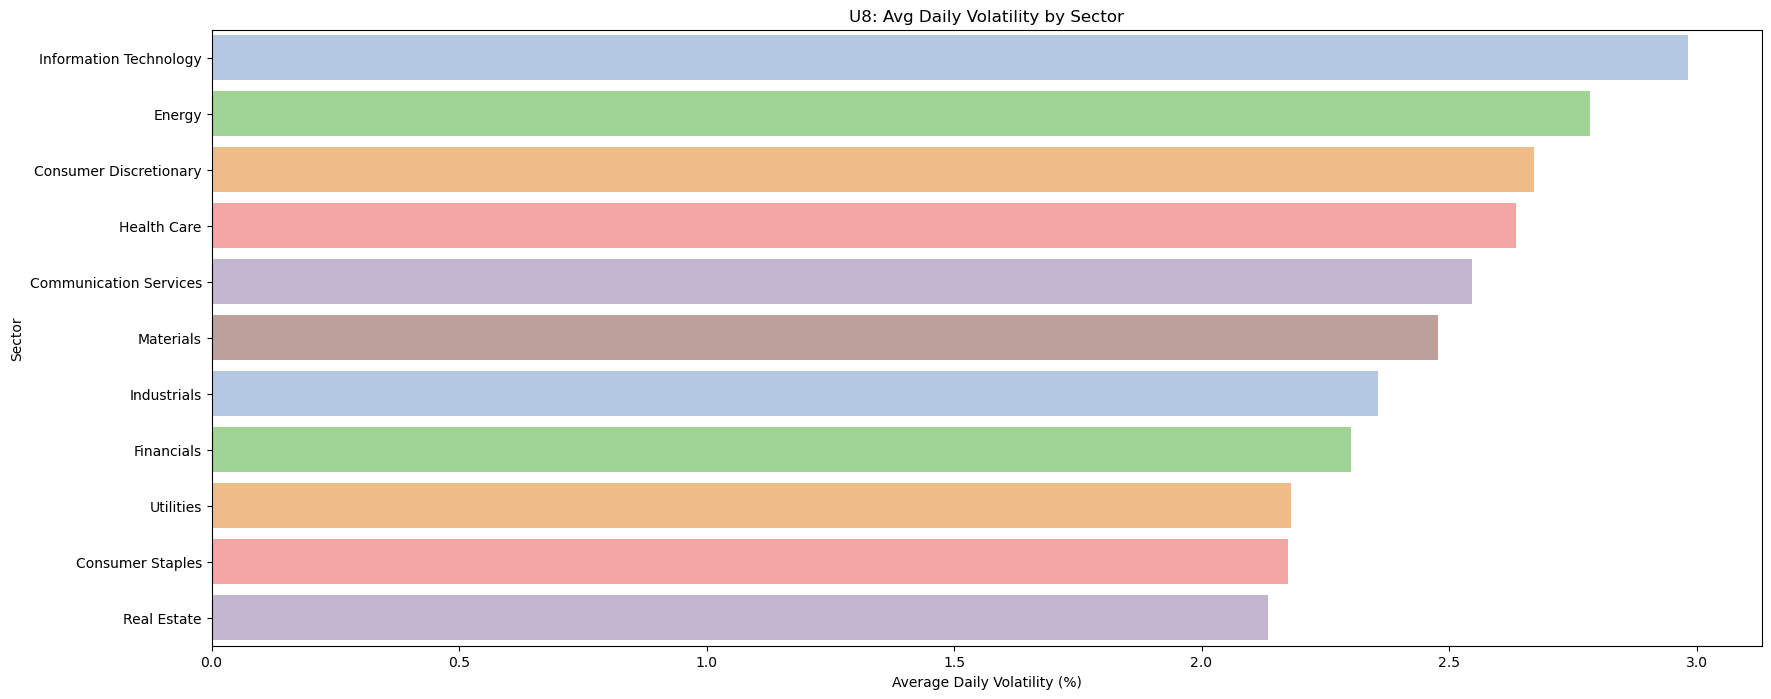

In [ ]:
plt.figure(figsize=(20, 8))
sns.barplot(
    x=avg_volatility_per_sector.values,
    y=avg_volatility_per_sector.index,
    palette=palette
)

plt.xlabel('Average Daily Volatility (%)')
plt.ylabel('Sector')
plt.title("U8: Avg Daily Volatility by Sector")
plt.show()


**Observation**
- A horizontal bar chart shows the average daily volatility of the 11 S&P 500 sectors.
- Cyclical sectors like Information Technology and Energy rank highest, while defensive sectors like Utilities, Consumer Staples, and Real Estate rank lowest.
- This highlights sector specific risk: high volatility sectors present greater short term trading opportunities and systemic risk, whereas low volatility sectors provide stability for capital preservation and income-focused strategies.

## 6.2 Bivariate

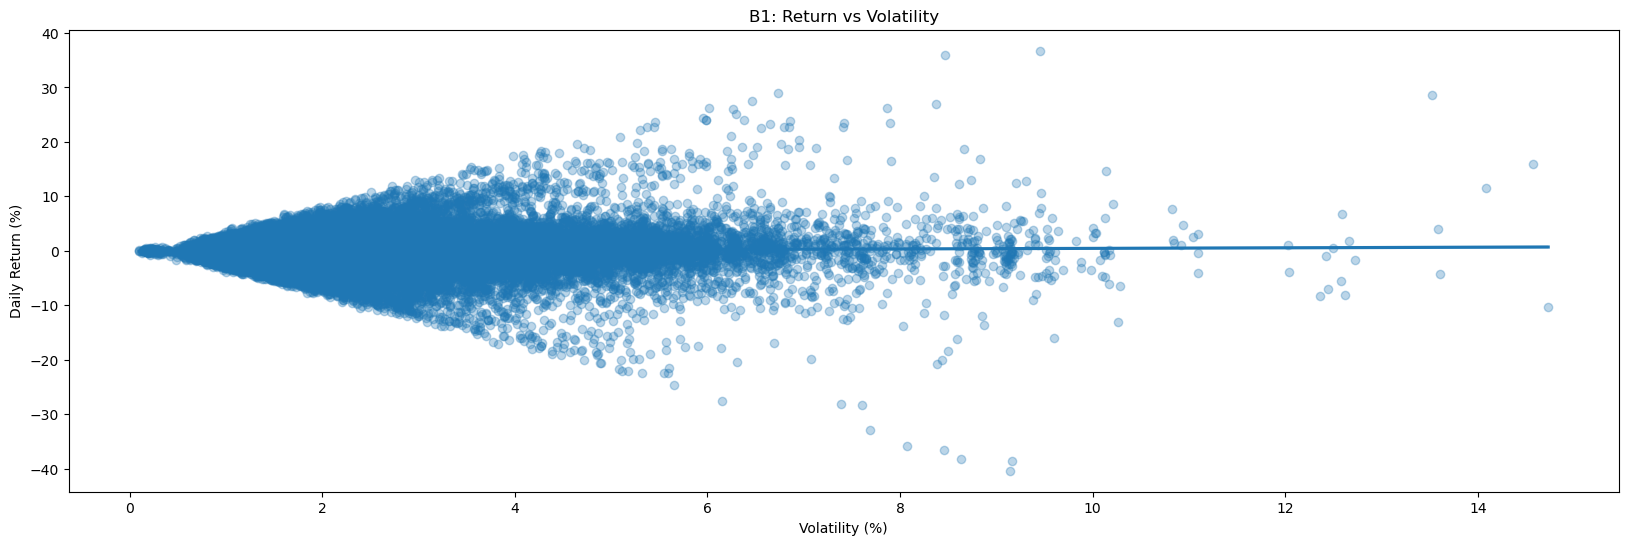

In [ ]:
# --- B1: Return vs Volatility ---
plt.figure(figsize=(20,6))
sns.regplot(x='Volatility (%)', y='Daily Return (%)', data=stock_df, scatter_kws={'alpha':0.3})
plt.title("B1: Return vs Volatility")
plt.show()

**Observation**
- A scatter plot shows the relationship between daily return and volatility.
- The points form a weakly positive slope, indicating a noisy but observable risk reward tradeoff.
- This suggests that higher volatility is generally associated with higher potential returns, aligning with modern portfolio theory principles.
- Stocks from high growth sectors like Technology and Communication Services show higher volatility but also higher returns, aligning with the expected riskreturn relationship observed in financial markets.

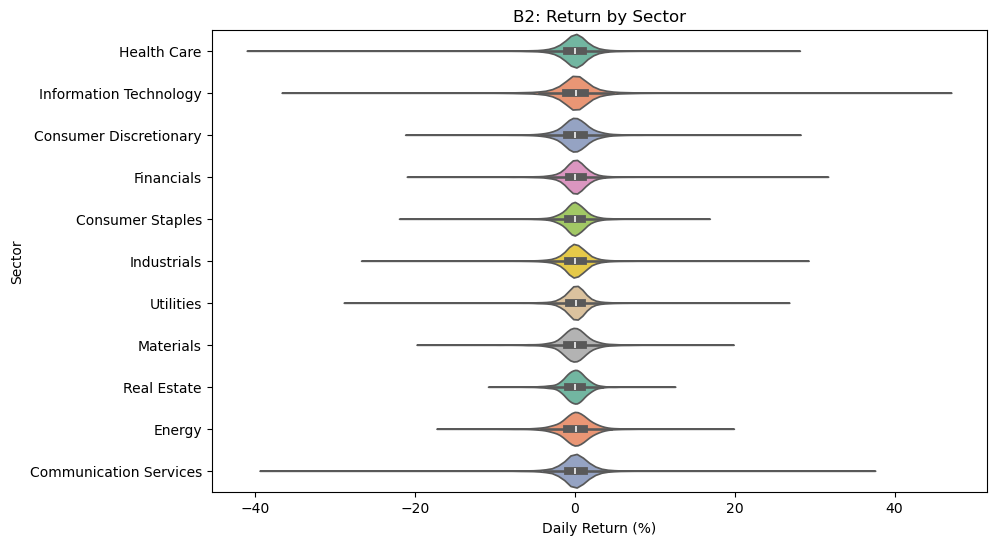

In [ ]:
# --- B2: Return by Sector ---
plt.figure(figsize=(10,6))
sns.violinplot(x='Daily Return (%)', y='Sector', data= stock_df, palette='Set2')
plt.title("B2: Return by Sector")
plt.show()

**Observation**
- A violin plot displays the distribution of daily returns across sectors.
- Defensive sectors such as Utilities and Consumer Staples have narrow return distributions, indicating stability. Growth oriented sectors such as Technology and Communication Services have wider, more asymmetric distributions, indicating higher risk and return potential.

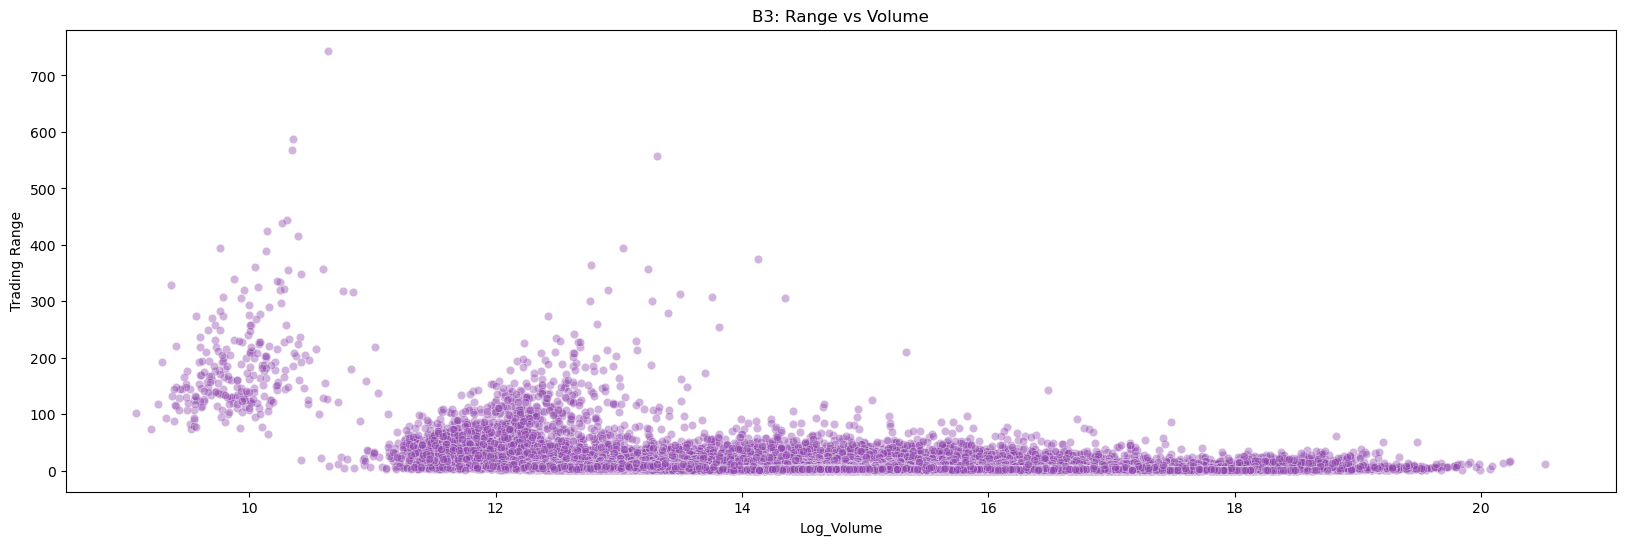

In [ ]:
# --- B3: Range vs Volume ---
plt.figure(figsize=(20,6))
sns.scatterplot(x='Log_Volume', y='Trading Range', data= stock_df, color='#8e44ad', alpha=0.4)
plt.title("B3: Range vs Volume")
plt.show()

**Observation**
- Scatter plot shows the relationship between trading range and log-transformed volume.  
- In this plot we can observe that the majority trading in the range of 30-40 and it is also observed that there are a very few data points that are being traded above the range of 100


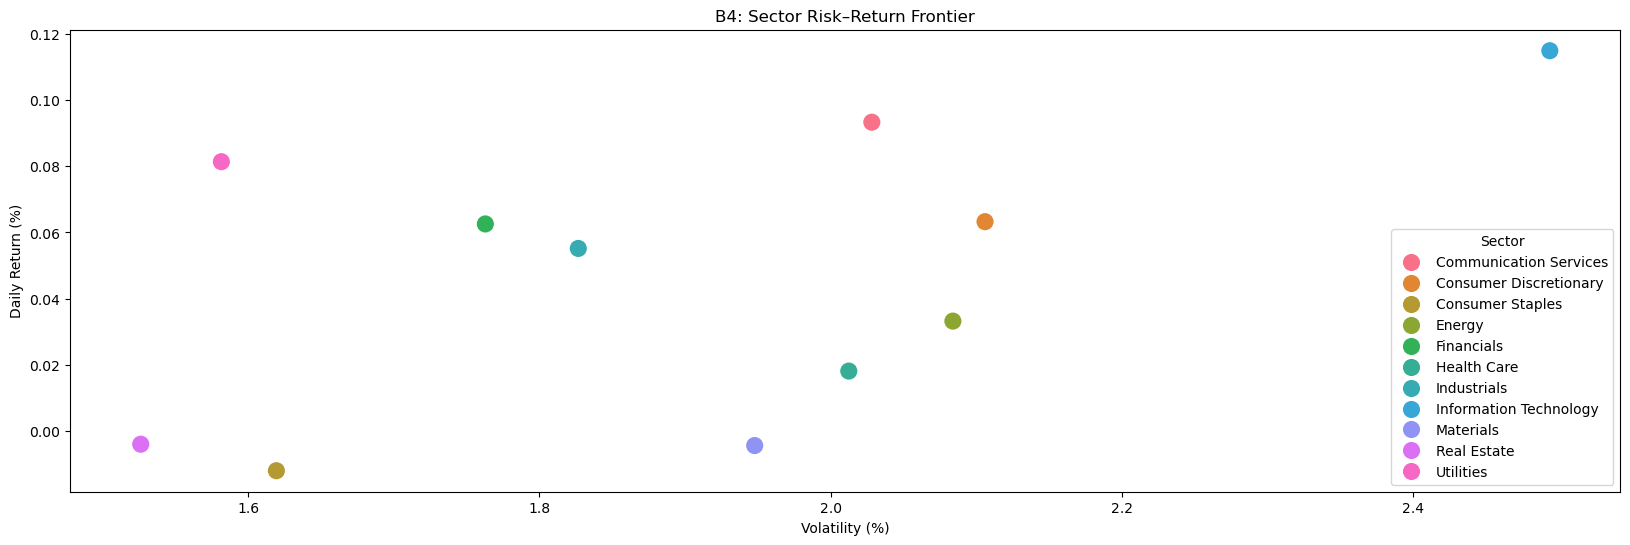

In [ ]:
# --- B4: Sector Risk–Return Frontier ---
sec_summary = stock_df.groupby('Sector')[['Daily Return (%)','Volatility (%)']].mean().reset_index()
plt.figure(figsize=(20,6))
sns.scatterplot(x='Volatility (%)', y='Daily Return (%)', hue='Sector', data=sec_summary, s=180)
plt.title("B4: Sector Risk–Return Frontier")
plt.show()

**Observation**
- Scatter plot displays sectors on a risk return plane.  
- With this, we can see the Risk Return on the data, the data points closer to the top left are the one's with Low risk and better returns (Stable Stocks)
- And the one's further are very volaitile and risky

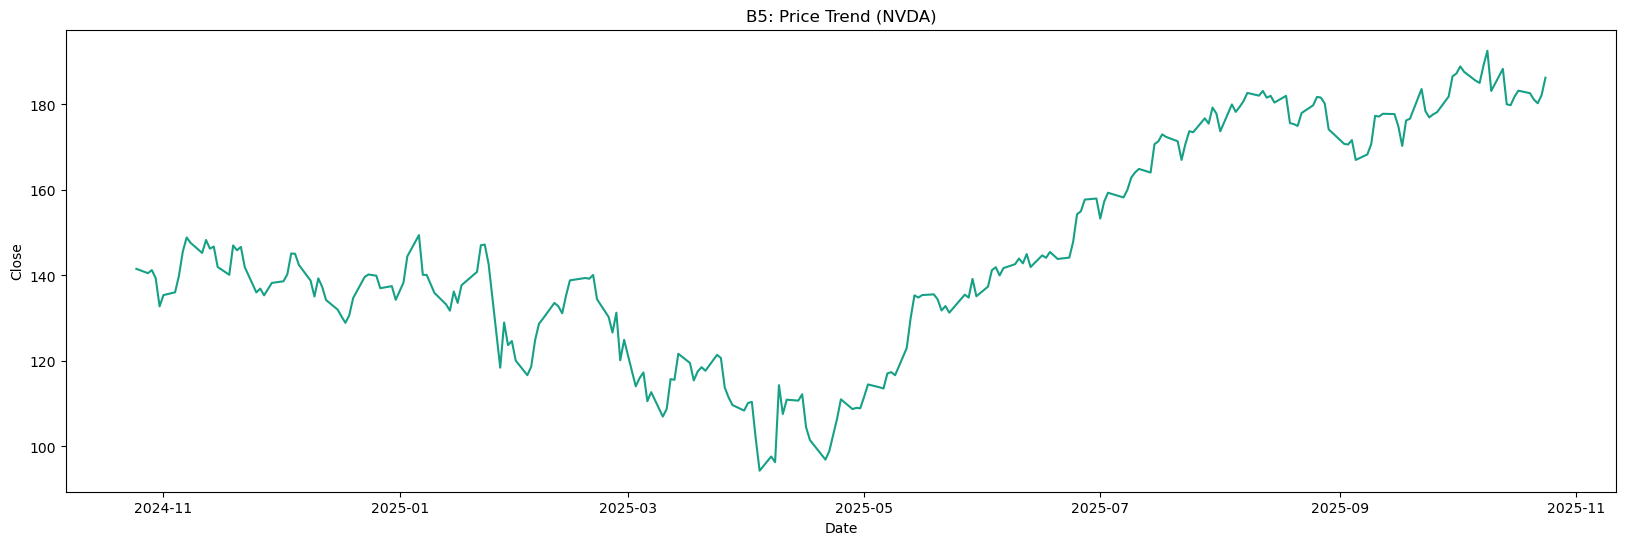

In [ ]:
# --- B5: Price Trend (Top Stock) ---
df_top = stock_df[stock_df['Ticker']==top5_tickers_by_volume[0]]
plt.figure(figsize=(20,6))
sns.lineplot(x='Date', y='Close', data=df_top, color='#16a085')
plt.title(f"B5: Price Trend ({top5_tickers_by_volume[0]})")
plt.show()

**Observation**
- Line plot shows the closing price trend for a top ticker.  
- The trend shows a sharp dip during April, but overall we see the stock price growing with time

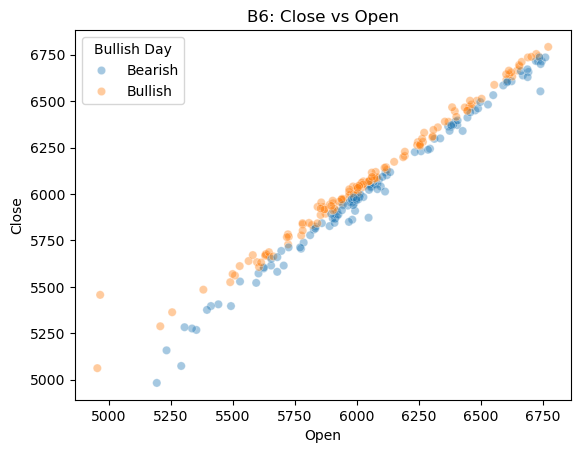

In [ ]:
# --- B6: Close vs Open ---
sns.scatterplot(x='Open', y='Close', hue='Bullish Day', data= market_df, alpha=0.4)
plt.title("B6: Close vs Open")
plt.show()

**Observation**
- Scatter plot shows Close vs. Open prices for daily movements.  
- Points are color coded for Bullish (Close > Open) and Bearish (Close < Open) days.  
- The plot highlights intra day market drift; they also show a linear pattern, revealing their linear effect on the market (Bullish or Bearish).

In [ ]:
df_unique_companies = df.drop_duplicates(subset=['Ticker']).copy()
df_unique_companies['Founded'] = pd.to_numeric(df_unique_companies['Founded'], errors='coerce')
df_unique_companies.dropna(subset=['Founded'], inplace=True)
df_unique_companies['Founding_Decade'] = df_unique_companies['Founded'].apply(lambda x: f"{int(x//10)*10}s")

In [ ]:
decade_sector_counts = df_unique_companies.groupby(['Founding_Decade','Sector']).size().reset_index(name='Count')
decade_order = sorted(df_unique_companies['Founding_Decade'].unique())
sector_order = df_unique_companies['Sector'].value_counts().index.tolist()

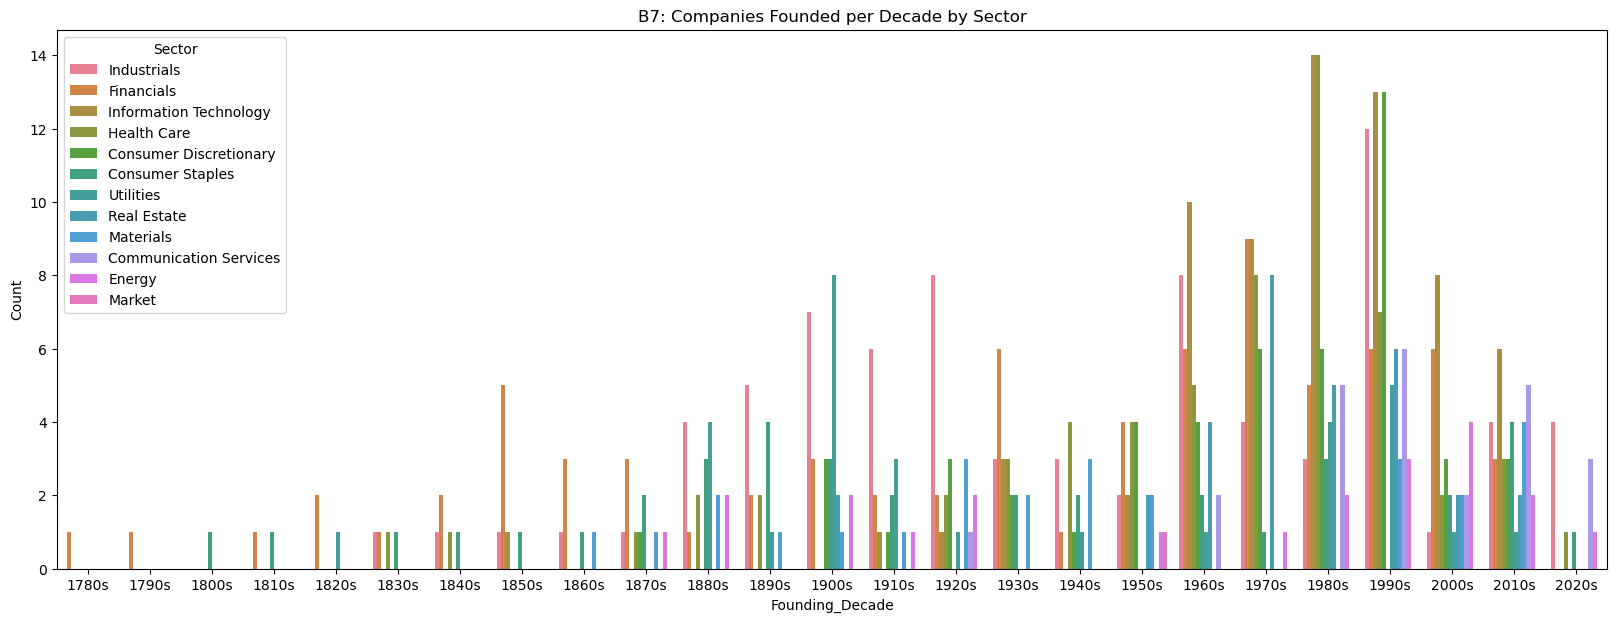

In [ ]:
# --- B7: Companies Founded per Decade by Sector ---
plt.figure(figsize=(20,7))
sns.barplot(
    x='Founding_Decade',
    y='Count',
    hue='Sector',
    data=decade_sector_counts,
    order=decade_order,
    hue_order=sector_order
)
plt.title("B7: Companies Founded per Decade by Sector")
plt.show()

**Observation**
- Grouped bar plot shows the count of S&P 500 companies founded per decade, segmented by sector.  
- Older sectors like Financials, Industrials, and Utilities dominate pre 1980s, while Technology and Healthcare grow rapidly from the 1990s onward.  
- The plot highlights sectoral evolution, innovation driven growth, and shifts in the U.S. economic landscape over time.

## 6.3 Multivariate

In [ ]:
heat = stock_df.groupby(['Sector', 'Year'])['Daily Return (%)'].mean().unstack(fill_value=0)

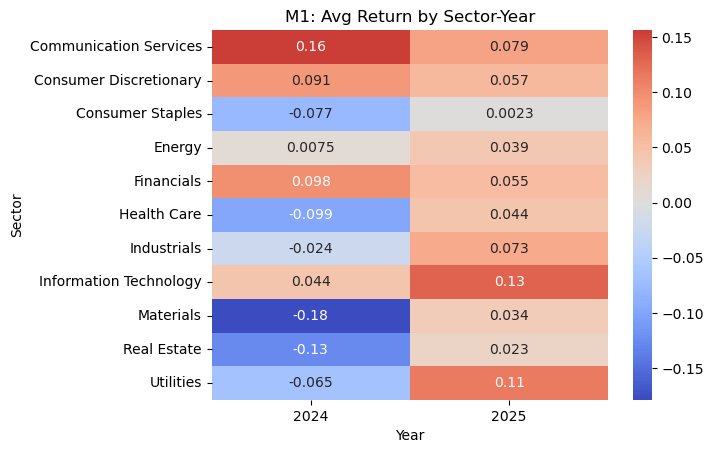

In [ ]:
# --- M1: Avg Return by Sector-Year (Heatmap) ---
sns.heatmap(heat, annot=True, cmap='coolwarm', center=0)
plt.title("M1: Avg Return by Sector-Year")
plt.show()

**Observation**
- The heatmap displays the average daily return for each sector across different years.  
- The Communication Services had strong positive returns in 2024(red shades) but slightly underperformed in 2025 (light red shade).
- Financials showed relatively steady performance across years with mild positive returns (mostly light red).
- Utilities and Energy sectors exhibited high volatility, with some years showing losses (light blue) and others gains (light red).

In [ ]:
heat = market_df.groupby(['Sector', 'Year'])['Daily Return (%)'].mean().unstack(fill_value=0)

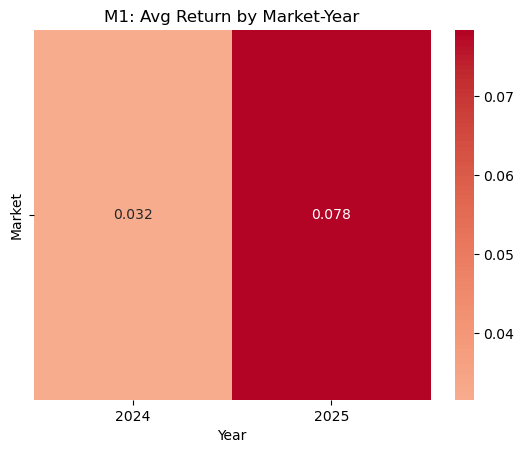

In [ ]:
sns.heatmap(heat, annot=True, cmap='coolwarm', center=0)
plt.title("M1: Avg Return by Market-Year")
plt.ylabel("")
plt.show()

**Observation**
- The heatmap illustrates the average daily returns across the market for each year. Overall, the market shows a positive trend in recent years, with the average return increasing from 0.032 in 2024 to 0.078 in 2025, indicating stronger market performance and improved investor sentiment. This upward shift suggests that the market gained momentum in 2025 compared to the previous year, reflecting broader growth across sectors.

In [ ]:
df_top5 = stock_df[stock_df['Ticker'].isin(top5_tickers_by_volume)].copy()
df_top5['SMA_20'] = df_top5.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).mean())
melted = df_top5.melt(id_vars=['Date', 'Ticker'], value_vars=['Close', 'SMA_20'], var_name='Metric', value_name='Price')

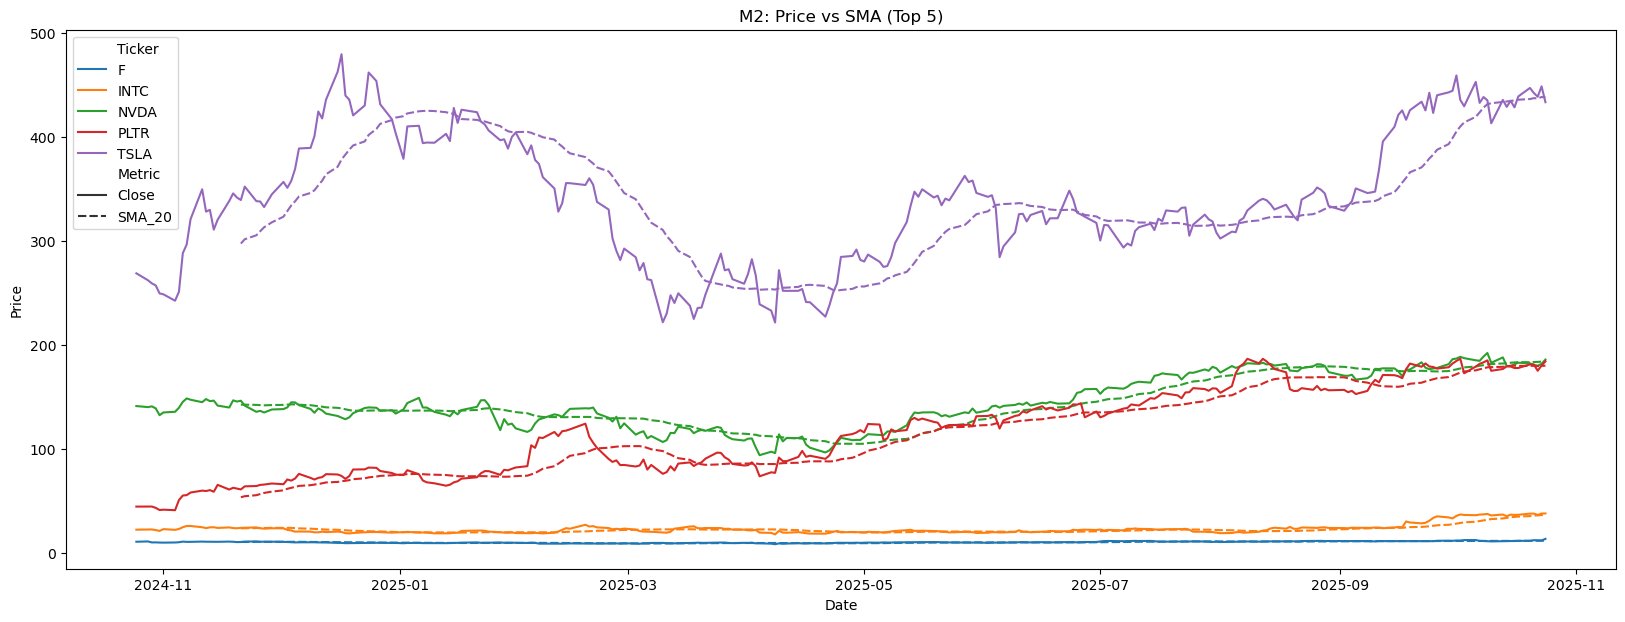

In [ ]:
# --- M2: Price vs SMA (Top 5) ---
plt.figure(figsize=(20,7))
sns.lineplot(x='Date', y='Price', hue='Ticker', style='Metric', data=melted)
plt.title("M2: Price vs SMA (Top 5)")
plt.show()

**Observation**
- The line plot shows the closing price trend for the top 5 tickers along with their 20-day Simple Moving Average (SMA).  
- The price line generally follows the SMA and occasionally crosses it, indicating short term trend changes.  
- This helps identify strong uptrends, potential reversals, and entry/exit points for momentum-based trading.
- TSLA is higly volatile and not stable, F, PLTR, INTC,NVDA is stable

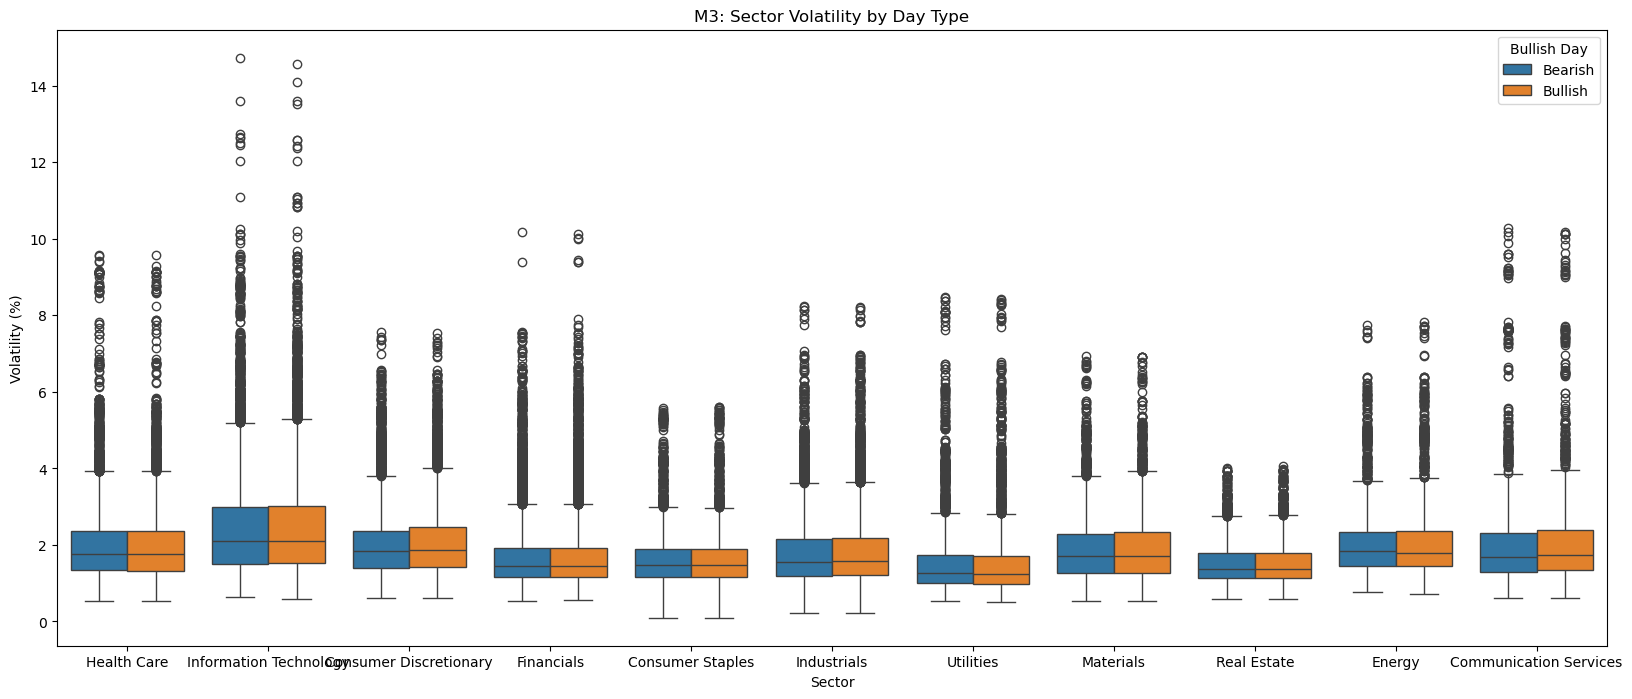

In [ ]:
# --- M3: Sector Volatility by Day Type ---
plt.figure(figsize=(20,8))
sns.boxplot(x='Sector', y='Volatility (%)', hue='Bullish Day', data=stock_df)
plt.title("M3: Sector Volatility by Day Type")
plt.show()

**Observation**
- The box plot compares sector wise volatility on bullish vs. bearish days.  
- Bearish days generally exhibit slightly higher median volatility across sectors.  
- This illustrates the asymmetric volatility (Leverage Effect), where market declines trigger larger intra-day price swings due to increased uncertainty.


In [ ]:
corr_cols = ['Daily Return (%)', 'Volatility (%)', 'Volume', 'Close', 'Open', 'High', 'Low']

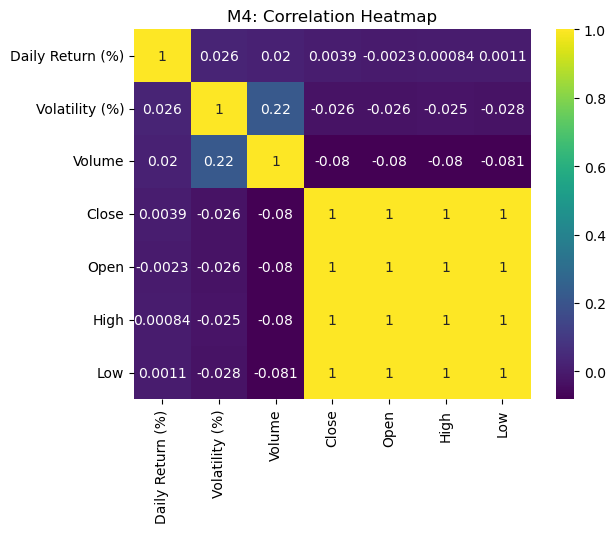

In [ ]:
# --- M4: Correlation Heatmap ---
sns.heatmap(stock_df[corr_cols].corr(), annot=True, cmap='viridis')
plt.title("M4: Correlation Heatmap")
plt.show()

**Observation**
- The heatmap shows correlations among key financial variables.  
- Open, High, Low, and Close are highly correlated (0.95+), while Volume has low correlation with Return.  
- This indicates efficient price discovery, with price movements driven primarily by fundamentals rather than trading volume alone.

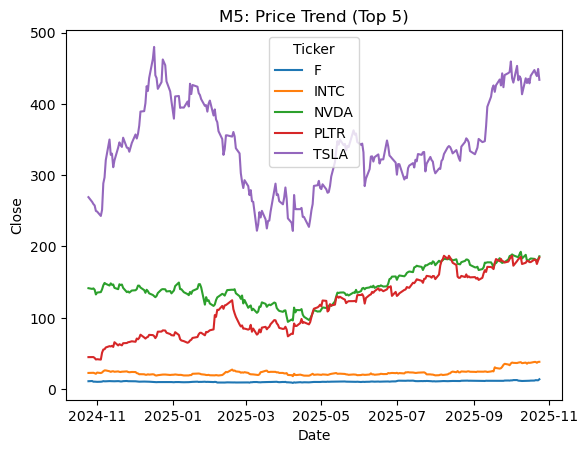

In [ ]:
# --- M5: Price Trend (Top 5) ---
sns.lineplot(x='Date', y='Close', hue='Ticker', data=stock_df[stock_df['Ticker'].isin(top5_tickers_by_volume)])
plt.title("M5: Price Trend (Top 5)")
plt.show()

**Observation**
- Line plots show the price trend of the top 5 tickers, split by year.  
- Each ticker exhibits distinct upward shifting trends across successive years.  
- This demonstrates the compounding power of growth, with each year starting at a higher baseline than the previous, highlighting long term positive skew in the equity markets.

## Summary of Visualizations:

**Daily Returns Distribution:** Daily returns are fat tailed and non normal, indicating higher likelihood of extreme positive or negative movements, especially in Technology, Financials, and Healthcare.

**Trading Volume:** Log-transformed trading volumes are right skewed, with occasional spikes driven by large cap stocks or news events.

**Daily Volatility:** Most stocks exhibit a tight median volatility, but sporadic extreme volatility occurs, particularly in Technology, Communication Services, and Energy.

**Sector Observation Counts:** Industrials and Financials dominate the dataset, highlighting sampling bias toward large sectors.

**Closing Prices:** Price distributions differ structurally across sectors, with high priced stocks in Technology and Consumer Discretionary versus lower priced stocks in Utilities and Real Estate.

**Day-of-Week Returns:** Mid week strength is observed; Wednesday and Monday show the highest returns, while Thursday and Friday experience mild declines.

**Sector Concentration:** Financials, Information Technology, and Healthcare dominate the S&P 500, indicating concentration risk in index performance.

**Sector Volatility:** Cyclical sectors (Technology, Energy) exhibit higher volatility, while defensive sectors (Utilities, Consumer Staples) are more stable.

**Risk-Return Relationship:** Higher volatility generally aligns with higher returns, especially in growth sectors like Technology and Communication Services.

**Sector Return Distributions:** Defensive sectors have narrow return distributions; growth sectors have wider, more asymmetric distributions indicating higher risk reward potential.

**Trading Range vs Volume:** Most trading occurs within moderate ranges (30–40), with few extreme outliers above 100.

**Sector Risk-Return Plane:** Some sectors offer low risk high return profiles (stable), while others are highly volatile and risky.

**Stock Price Trends:** Top tickers generally show upward trends, with short term dips; SMA analysis identifies trend shifts and potential trading signals.

**Market Correlations:** Prices (Open, High, Low, Close) are highly correlated, while Volume shows low correlation with returns, indicating fundamental driven price movements.

**Historical and Sector Evolution:** Older sectors like Financials, Industrials, and Utilities dominate pre-1980s; Technology and Healthcare expand rapidly post-1990s, reflecting innovation-driven growth.


Overall, the visualizations revealed that the S&P 500 is a non-normal, volatility-driven market with strong sectoral differences.

Growth sectors offer high reward but high volatility, while defensive sectors provide stability.

Market behavior shows clear temporal patterns, structural sector evolution, and strong price correlations.

These insights lay the foundation for deeper predictive analysis, portfolio decisions, and risk-management strategies

# 7. Data Mining

### 1. Which sector had the highest average stock return in the past year?

In [ ]:
# Annual return by stock， (adj close last - adj close first)/adj close first
annual_return = (
    stock_df.groupby('Ticker')['Adj Close']
    .agg(lambda x: x.iloc[-1] / x.iloc[0] - 1)
    .reset_index(name='AnnualReturn')
)

annual_return = annual_return.merge(stock_df[['Ticker','Sector']].drop_duplicates(), on='Ticker')

In [ ]:
annual_return

,Ticker,AnnualReturn,Sector
0,A,0.146275,Health Care
1,AAPL,0.141009,Information Technology
2,ABBV,0.256143,Health Care
3,ABNB,-0.048967,Consumer Discretionary
4,ABT,0.131579,Health Care
...,...,...,...
498,XYZ,0.095441,Financials
499,YUM,0.098544,Consumer Discretionary
500,ZBH,0.016175,Health Care
501,ZBRA,-0.142381,Information Technology


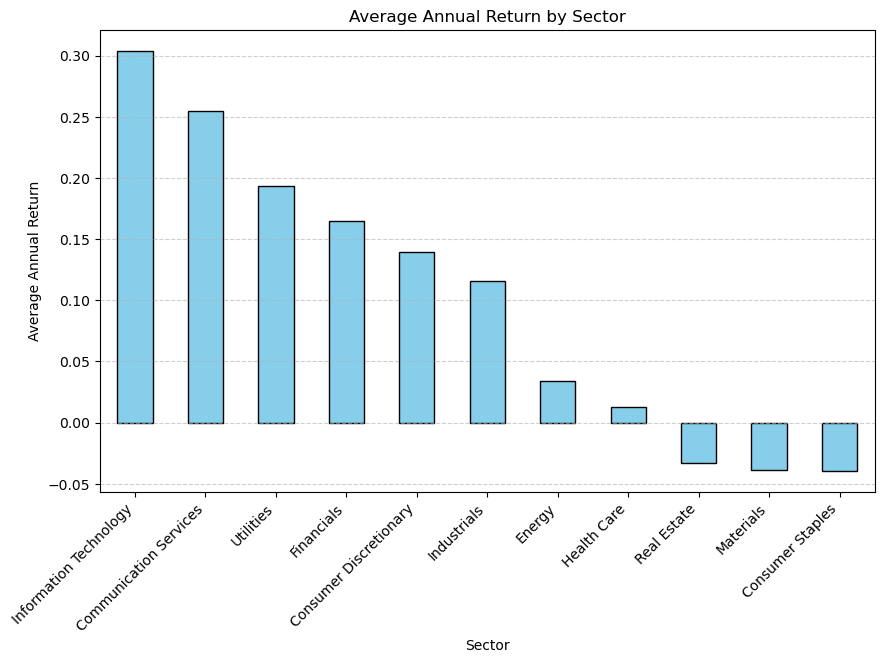

In [ ]:
# Average by sector
sector_return = annual_return.groupby('Sector')['AnnualReturn'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sector_return.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Annual Return by Sector')
plt.ylabel('Average Annual Return')
plt.xlabel('Sector')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Observation**
- From the plot above, we can see that Information Technology and Communication Services sectors achieved the highest annual returns, showing strong market growth driven by tech innovation.
- Utilities and Financials performed moderately well, while Real Estate, Materials, and Consumer Staples showed slight declines.
- Overall, tech-related sectors outperformed defensive industries.

### 2. Which sector showed the largest price volatility?

In [ ]:
# Volatility = std of daily returns
volatility = stock_df.groupby('Ticker')['Return'].std().reset_index(name='Volatility')

In [ ]:
# merge with sector
volatility = volatility.merge(stock_df[['Ticker','Sector']].drop_duplicates(), on='Ticker')

In [ ]:
# Group by sector and calculate volatility
sector_vol = volatility.groupby('Sector')['Volatility'].mean().sort_values(ascending=False)

In [ ]:
sector_vol.head(10)

Sector
Information Technology    0.027212
Consumer Discretionary    0.022521
Energy                    0.022360
Communication Services    0.021953
Health Care               0.021569
Materials                 0.020907
Industrials               0.019834
Financials                0.019191
Consumer Staples          0.016903
Utilities                 0.016626
Name: Volatility, dtype: float64

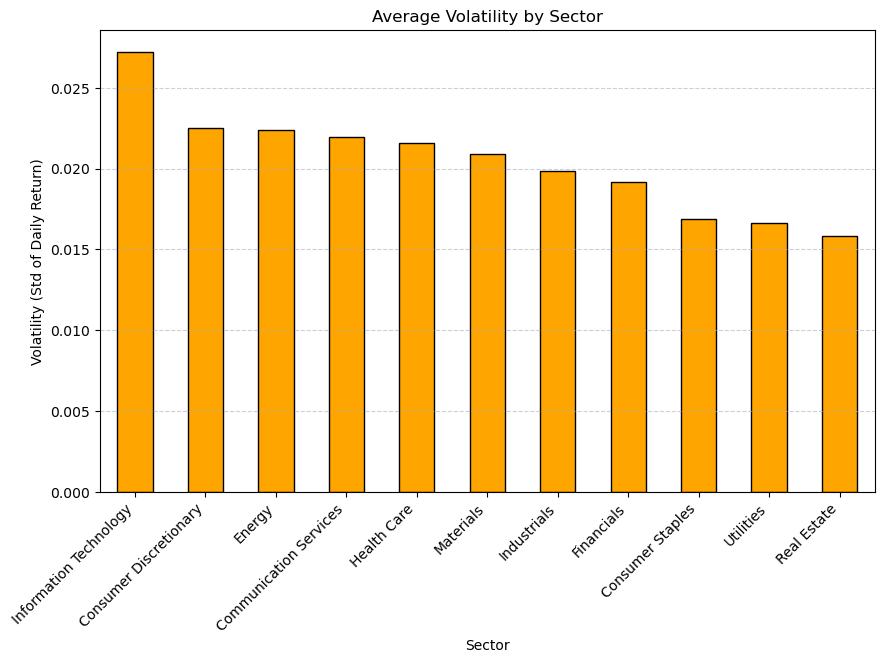

In [ ]:
plt.figure(figsize=(10,6))
sector_vol.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Volatility by Sector')
plt.ylabel('Volatility (Std of Daily Return)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Observation**
- Information Technology and Consumer Discretionary sectors showed the highest price volatility, indicating more frequent and larger price fluctuations within these industries.
- In contrast, Utilities and Real Estate sectors had the lowest volatility, reflecting more stable and predictable price movements.
- Overall, growth-oriented sectors tend to experience higher risk and variability compared to defensive sectors.

### 3. How did the average stock prices change month by month across sectors?

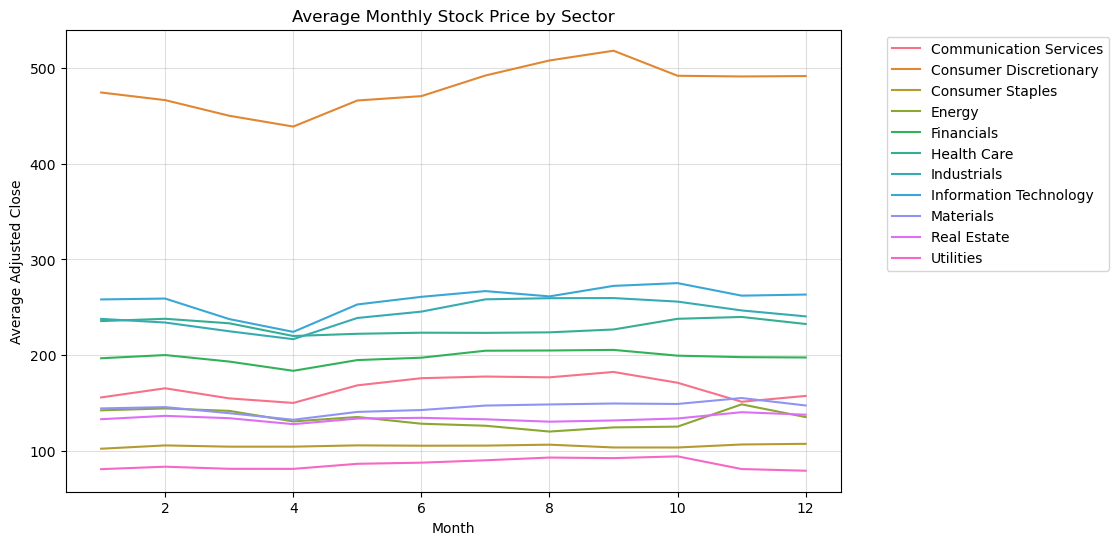

In [ ]:
# average adj close price for each sector and each month
monthly_sector = stock_df.groupby(['Sector','Month'])['Adj Close'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(x='Month', y='Adj Close', hue='Sector', data=monthly_sector)
plt.title('Average Monthly Stock Price by Sector')
plt.ylabel('Average Adjusted Close')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(alpha=0.4)
plt.show()

**Observation**
- Across most sectors, average stock prices remained relatively stable month to month.
- Technology and Consumer discretionary maintained the highest average prices, showing steady growth mid-year.
- In contrast, Real Estate and Utilities stayed consistently lower, reflecting weaker market performance.

### 4. Which sector has the most stable growth (low volatility but positive return)?

In [ ]:
# Combine sector average return and volatility
sector_summary = pd.merge(
    sector_return.reset_index(),
    sector_vol.reset_index(),
    on='Sector'
)

In [ ]:
# rename
sector_summary.columns = ['Sector','AverageReturn','Volatility']

In [ ]:
# calculate the stability score
sector_summary['stability_score'] = sector_summary['AverageReturn'] / sector_summary['Volatility']

In [ ]:
# sort
sector_summary = sector_summary.sort_values(['stability_score','AverageReturn'], ascending=False)
sector_summary

,Sector,AverageReturn,Volatility,stability_score
2,Utilities,0.193452,0.016626,11.635722
1,Communication Services,0.254600,0.021953,11.597683
0,Information Technology,0.303783,0.027212,11.163576
3,Financials,0.165121,0.019191,8.603967
4,Consumer Discretionary,0.139848,0.022521,6.209716
5,Industrials,0.115571,0.019834,5.826815
6,Energy,0.034006,0.022360,1.520875
7,Health Care,0.013012,0.021569,0.603307
9,Materials,-0.038951,0.020907,-1.863034
8,Real Estate,-0.032985,0.015849,-2.081133


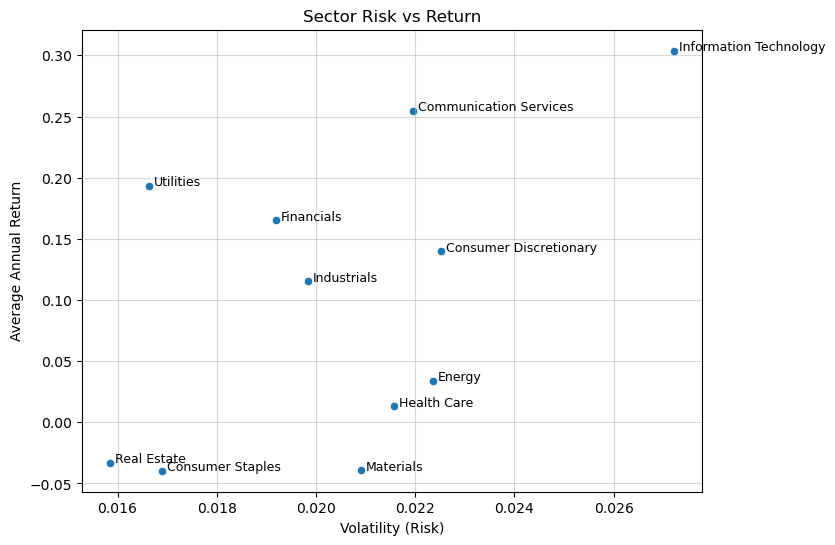

In [ ]:
# plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Volatility', y='AverageReturn', data=sector_summary)
plt.title('Sector Risk vs Return')
for i in range(len(sector_summary)):
    plt.text(sector_summary['Volatility'][i]+0.0001, # set x for text
             sector_summary['AverageReturn'][i],     # set y for text
             sector_summary['Sector'][i], fontsize=9)    # show sector name
plt.xlabel('Volatility (Risk)')
plt.ylabel('Average Annual Return')
plt.grid(alpha=0.5)
plt.show()

**Observation**
- Utilities sector shows the most stable growth, featuring low volatility and a relatively high positive return.
- Information Technology and Communication Services sectors achieved the highest returns but also had higher risks, while Real Estate and Consumer Staples remained stable but underperforming.

### 5. What is the distribution of annual returns across all companies?


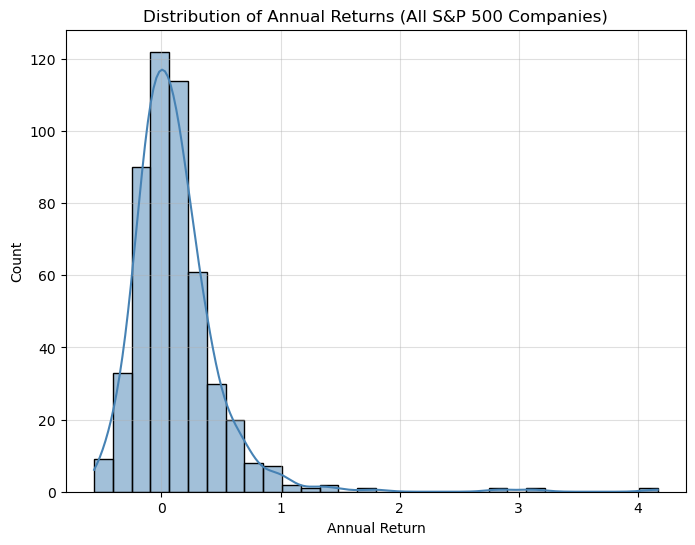

,Ticker,AnnualReturn,Sector
225,HOOD,4.165928,Financials
372,PLTR,3.115693,Information Technology
39,APP,2.835922,Information Technology
480,WBD,1.782895,Communication Services
482,WDC,1.472870,Information Technology
420,STX,1.327931,Information Technology
442,TPR,1.313168,Consumer Discretionary
44,AVGO,1.067067,Information Technology
327,MU,1.038154,Information Technology
201,GEV,0.995527,Industrials


In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(annual_return['AnnualReturn'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Annual Returns (All S&P 500 Companies)')
plt.xlabel('Annual Return')
plt.ylabel('Count')
plt.grid(alpha=0.4)
plt.show()

annual_return.sort_values('AnnualReturn', ascending=False).head(10)

In [ ]:
annual_return['AnnualReturn'].describe()

count    503.000000
mean       0.117894
std        0.396456
min       -0.564744
25%       -0.098602
50%        0.064377
75%        0.240202
max        4.165928
Name: AnnualReturn, dtype: float64

**Observation**
- The distribution of annual returns among all S&P 500 companies is right-skewed, indicating that while most companies experienced modest or slightly positive returns, a few companies achieved exceptionally high gains.
- The majority of returns cluster around 0, showing that most companies had limited growth during the year. However, several outliers—such as Robinhood (HOOD), Palantir (PLTR), and AppLovin (APP)—recorded extremely high annual returns, exceeding 100% to 400%, mainly from the Information Technology and Financials sectors.
- This suggests that overall market performance was moderate, but technology-driven companies demonstrated substantial upside volatility and dominated the top-performing group.

### 6. Which companies had the highest and lowest annual return?

We compute the annual return for each ticker as:

\begin{equation}
\text{Annual Return} = \frac{\text{Last Adj Close} - \text{First Adj Close}}{\text{First Adj Close}}
\end{equation}

We sort the results to find the **top 10** and **bottom 10** performers.

In [ ]:
# Sort by date and group by ticker
returns = []
for ticker, g in df.groupby('Ticker'):
    g = g.dropna(subset=['Close'])
    if len(g) == 0:
        continue
    first = g.iloc[0]['Close']
    last = g.iloc[-1]['Close']
    annual_return1 = (last - first) / first
    returns.append((ticker, g['Company'].iloc[0], g['Sector'].iloc[0], annual_return1))

In [ ]:
ret_df = pd.DataFrame(returns, columns=['Ticker', 'Company', 'Sector', 'AnnualReturn'])
ret_df = ret_df.sort_values('AnnualReturn', ascending=False).reset_index(drop=True)

In [ ]:
print('Top 10 companies by annual return:')
display(ret_df.head(10))

print('\nBottom 10 companies by annual return:')
display(ret_df.tail(10))

Top 10 companies by annual return:


,Ticker,Company,Sector,AnnualReturn
0,HOOD,Robinhood Markets,Financials,4.165928
1,PLTR,Palantir Technologies,Information Technology,3.115693
2,APP,AppLovin,Information Technology,2.835922
3,WBD,Warner Bros. Discovery,Communication Services,1.782895
4,WDC,Western Digital,Information Technology,1.465803
5,STX,Seagate Technology,Information Technology,1.272789
6,TPR,"Tapestry, Inc.",Consumer Discretionary,1.271935
7,AVGO,Broadcom,Information Technology,1.046994
8,MU,Micron Technology,Information Technology,1.029654
9,GEV,GE Vernova,Industrials,0.990836



Bottom 10 companies by annual return:


,Ticker,Company,Sector,AnnualReturn
494,STZ,Constellation Brands,Consumer Staples,-0.416743
495,BF-B,Brown–Forman,Consumer Staples,-0.422162
496,LYB,LyondellBasell,Materials,-0.456114
497,CNC,Centene Corporation,Health Care,-0.469480
498,DECK,Deckers Brands,Consumer Discretionary,-0.482839
499,MRNA,Moderna,Health Care,-0.496327
500,MOH,Molina Healthcare,Health Care,-0.498310
501,DOW,Dow Inc.,Materials,-0.500805
502,IT,Gartner,Information Technology,-0.512603
503,TTD,Trade Desk (The),Communication Services,-0.564744


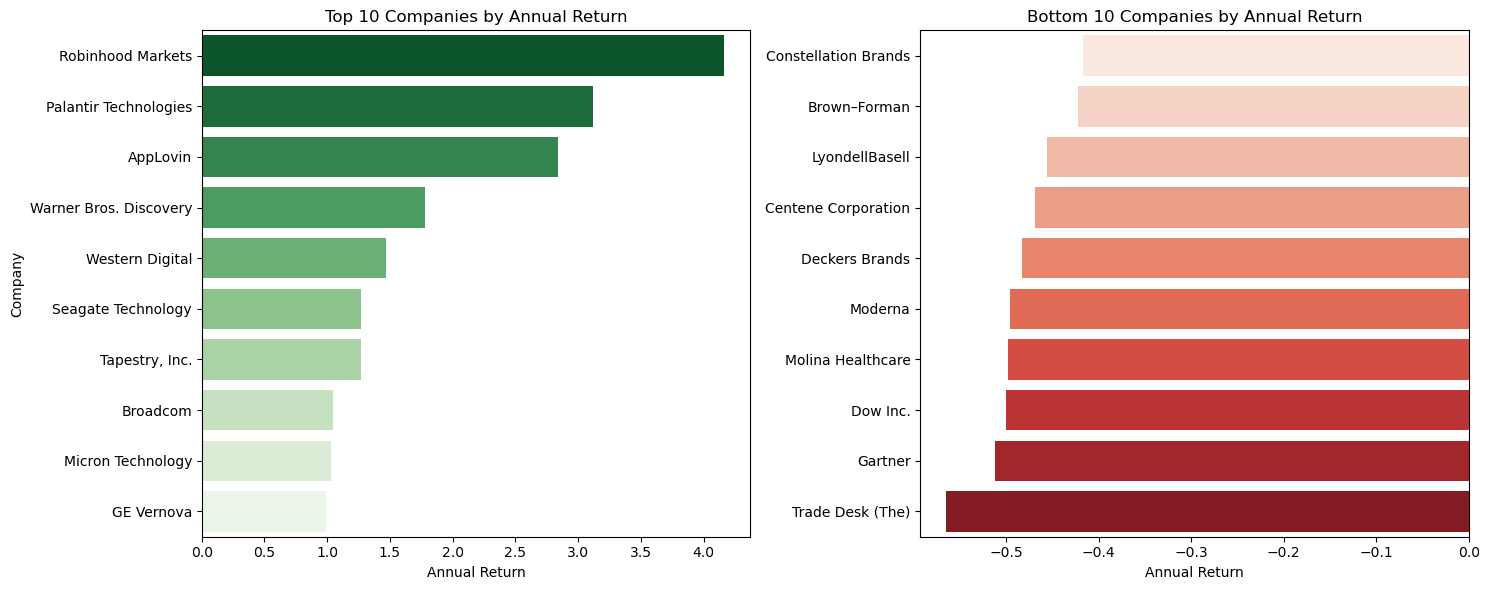

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,6))
sns.barplot(y='Company', x='AnnualReturn', data=ret_df.head(10), ax=ax[0], palette='Greens_r')
ax[0].set_title('Top 10 Companies by Annual Return')
ax[0].set_xlabel('Annual Return')
ax[0].set_ylabel('Company')

sns.barplot(y='Company', x='AnnualReturn', data=ret_df.tail(10), ax=ax[1], palette='Reds')
ax[1].set_title('Bottom 10 Companies by Annual Return')
ax[1].set_xlabel('Annual Return')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Observation**
- Robinhood Market had the highest annual return with over 400%, Trade Desk had the worst performance this year, return declined by more than 50%.

### 7. From 6, how did the highest annual return stock’s price change throughout the year? (or were there any specific months or quarters where most of the growth occurred?)


Next, we look at how the stock with the highest annual return behaved throughout the year.
We plot its **daily closing price** over time and visually inspect periods of fastest growth.

In [ ]:
# Select the highest-return stock
top_stock = ret_df.iloc[0]
top_ticker = top_stock['Ticker']
top_name = top_stock['Company']

# define top ticker df
top_hist = df[df['Ticker'] == top_ticker]

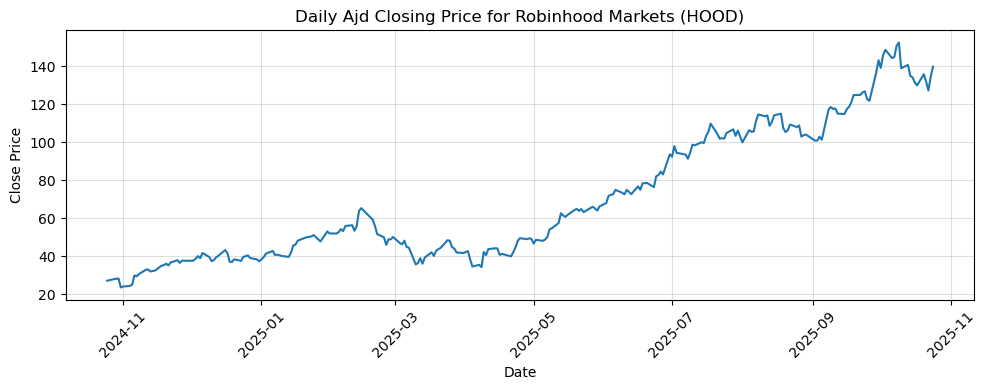

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(top_hist['Date'], top_hist['Adj Close'])
plt.title(f'Daily Ajd Closing Price for {top_name} ({top_ticker})')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Compute average monthly return to find which months saw the most growth
monthly_growth = top_hist.groupby('Month')['Return'].mean().reset_index()

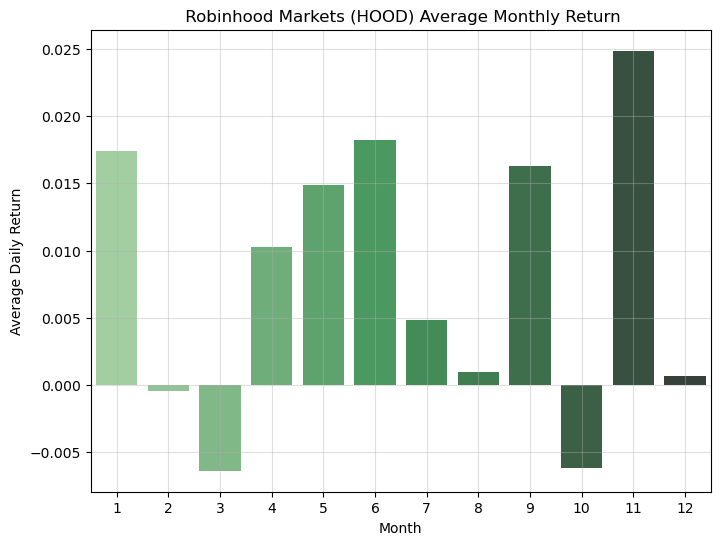

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x='Month', y='Return', data=monthly_growth, palette='Greens_d')
plt.title(f' {top_name} ({top_ticker}) Average Monthly Return')
plt.xlabel('Month')
plt.ylabel('Average Daily Return')
plt.grid(alpha=0.4)
plt.show()

**Observation**
- The closing price of Robinhood Markets shows a strong upward trend over the year, with several short consolidation periods.
- The steepest growth appears from late spring into early fall 2025, where the price accelerates sharply.
- Despite occasional pullbacks, the overall trajectory remains strongly positive, consistent with its very high annual return.

### 8. Do companies founded earlier perform differently from newer ones?


To explore this, we compare **founding year** vs **annual return**:
- Merge the annual returns with the `Founded` column.
- Make a scatter plot of `Founded` vs `AnnualReturn`.
- Look for patterns (e.g., newer companies clustering with higher returns).

In [ ]:
# Calculate company age
df_founded = df[['Ticker', 'Founded', 'Age']].drop_duplicates()
merged = ret_df.merge(df_founded, on='Ticker', how='left')

In [ ]:
merged['AgeGroup'] = pd.cut(
    merged['Age'],
    bins=[0,50,100,200],
    labels=['New (<50y)','Mid (50-100y)','Old (>100y)']
)


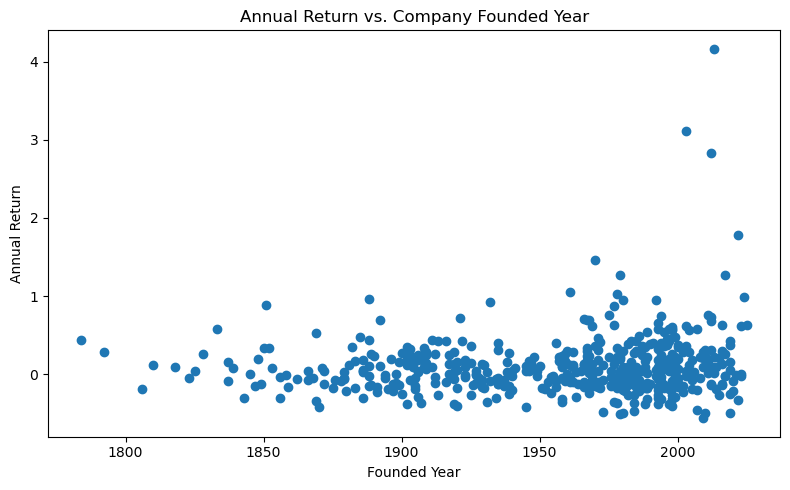

,Ticker,Company,Founded,AnnualReturn
0,HOOD,Robinhood Markets,2013,4.165928
1,PLTR,Palantir Technologies,2003,3.115693
2,APP,AppLovin,2012,2.835922
3,WBD,Warner Bros. Discovery,2022,1.782895
4,WDC,Western Digital,1970,1.465803


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(merged['Founded'], merged['AnnualReturn'])
plt.xlabel('Founded Year')
plt.ylabel('Annual Return')
plt.title('Annual Return vs. Company Founded Year')
plt.tight_layout()
plt.show()

merged[['Ticker', 'Company', 'Founded', 'AnnualReturn']].head()

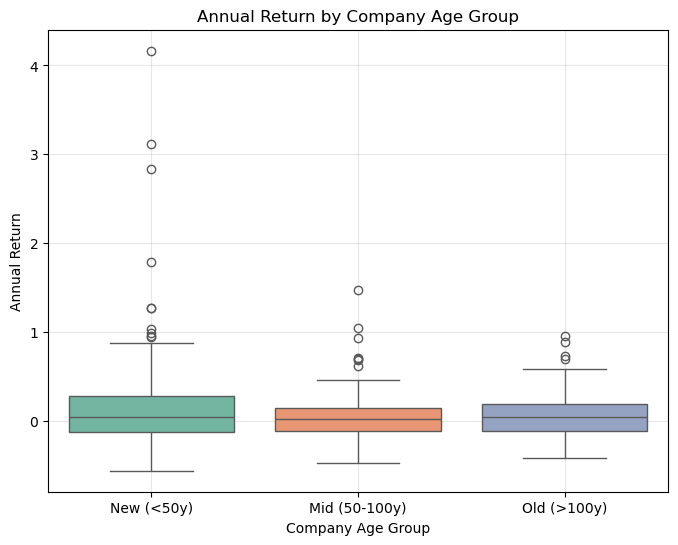

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='AgeGroup', y='AnnualReturn', data=merged, palette='Set2')
plt.title('Annual Return by Company Age Group')
plt.xlabel('Company Age Group')
plt.ylabel('Annual Return')
plt.grid(alpha=0.3)
plt.show()

**Observation**
- Founding years range from the late 1700s to the early 2000s, with a median around the late 1960s.
- The scatterplot suggests that many of the extreme positive returns are associated with relatively younger companies, often in fast-growing industries.
- Older, more established firms tend to cluster around moderate returns, with fewer extreme winners or losers compared with newer entrants.

### 9. Which months had the highest overall market growth?


To find the months with the highest overall market growth, we:
- Compute **daily returns** per stock using percentage change of `Close` within each ticker.
- Take the **average daily return across all stocks** for each month.
- Identify the strongest and weakest months.

In [ ]:
monthly_market_return = (
    market_df.groupby('Month')['Return']
      .mean()
      .reset_index(name='AverageMonthlyReturn')
)

In [ ]:
# Sort months by performance
monthly_market_return_sorted = monthly_market_return.sort_values('AverageMonthlyReturn', ascending=False)

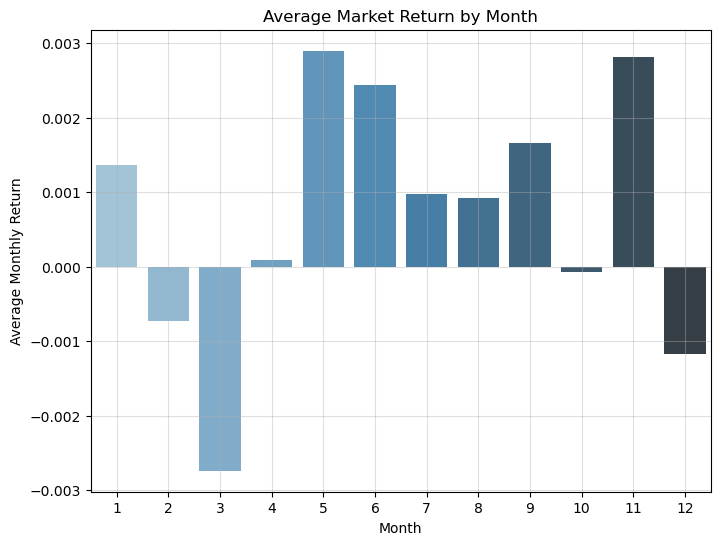

Top performing months:
     Month  AverageMonthlyReturn
4       5              0.002899
10     11              0.002817
5       6              0.002442


In [ ]:
# Visualization
plt.figure(figsize=(8,6))
sns.barplot(x='Month', y='AverageMonthlyReturn', data=monthly_market_return, palette='Blues_d')
plt.title('Average Market Return by Month')
plt.xlabel('Month')
plt.ylabel('Average Monthly Return')
plt.grid(alpha=0.4)
plt.show()

print("Top performing months:\n", monthly_market_return_sorted.head(3))

**Observation**
- Average daily returns by month fluctuate close to zero, suggesting that the overall market is relatively stable on a day-to-day basis.
- November 2024 shows the highest average daily return, while December 2024 records the lowest, indicating short periods of stronger gains and weaker performance.
- Months in 2025 generally exhibit small positive averages, hinting at a mild recovery after earlier volatility.

### 10. How did total trading volume change throughout the year?

Finally, we analyze how **total trading volume** changes throughout the year:
- Sum `Volume` for each month.
- Plot the monthly total volumes.
- Observe any peaks or trends.

In [ ]:
# Monthly total trading volume
market_df['Month'] = df['Date'].dt.to_period('M')

monthly_volume = (
    market_df.groupby('Month')['Volume']
      .sum()
)

In [ ]:
print('Total trading volume per month:')
monthly_volume

Total trading volume per month:


Month
2024-10     19348440000
2024-11     84101980000
2024-12     86064900000
2025-01     88639380000
2025-02     92317000000
2025-03    111387270000
2025-04    118936380000
2025-05    105346260000
2025-06    106456300000
2025-07    114004890000
2025-08     99352030000
2025-09    114074610000
2025-10     99943970000
Freq: M, Name: Volume, dtype: int64

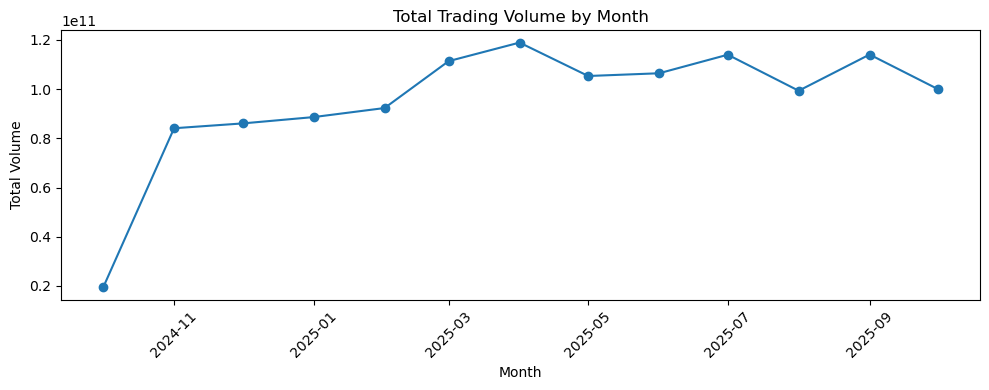

In [ ]:
# Plot monthly total volume
plt.figure(figsize=(10, 4))
monthly_volume.index = monthly_volume.index.to_timestamp()
plt.plot(monthly_volume.index, monthly_volume.values, marker='o')
plt.title('Total Trading Volume by Month')
plt.xlabel('Month')
plt.ylabel('Total Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Observation**
- Total trading volume increases sharply from October 2024 and reaches its peak around April 2025.
- After April, monthly volume gradually declines but stays higher than the very beginning of the sample.
- The spike in March–April 2025 likely corresponds to periods of heightened market activity, such as earnings announcements or macroeconomic news that affect many companies at once.

# 8. Conclusion

**Overall Market Trends**
1. The overall S&P 500 market showed moderate positive growth over the past year, with the average annual return across all companies around 12%.
2. Market volatility remained high, reflecting macroeconomic uncertainty such as inflation pressure and interest rate adjustments.
3. The majority of daily returns were concentrated between -2% and +2%, indicating a relatively stable market with few extreme fluctuations.
4. The market-wide trading volume peaked during earnings seasons (March-April), suggesting stronger investor reactions to corporate financial reports.
5. Prices (Open, High, Low, Close) are highly correlated, while Volume shows low correlation with returns, indicating fundamental driven price movements.

**Sector-Level Insights**
1. Information Technology and Communication Services sectors had the highest average annual returns, exceeding 25–30%, driven by AI and digital innovation.
2. Utilities sector demonstrated the most stable growth, maintaining low volatility and consistent positive return — ideal for risk-averse investors.
3. Real Estate, Materials and Consumer Staples sectors showed negative growth, affected by higher borrowing costs and weak consumer sentiment.
4. Energy sector had mixed performance, with returns largely influenced by oil price fluctuations and global commodity demand.
5. Older sectors like Financials, Industrials, and Utilities dominate pre-1980s; Technology and Healthcare expand rapidly post-1990s, reflecting innovation-driven growth. And a large number of companies were founded during the 1980s and 1990s, marking a period of economic recovery and rapid industrial expansion.
6. In S&P 500 companies list, Industrials and Financials sectors had the largest amount of companies.

**Company-Level Insights**
1. The top-performing companies, such as Robinhood, Palantir, AppLovin achieved extraordinary annual returns above 200%–400%, significantly outperforming the market average.
2. The bottom 10 companies mostly came from Health Care, Consumer Staples, and Materials sectors, with annual losses ranging from -40% to -56%, reflecting limited growth potential in traditional industries.
3. Older companies (founded before 1950) tended to exhibit lower volatility and steady but modest returns, consistent with their mature business models.
4. Younger companies (founded after 2000) showed higher volatility and a wider return range, indicating stronger innovation-driven opportunities but higher risk.
5. Top 5 highest trading Volume tickers are 'NVDA', 'TSLA', 'INTC', 'F', 'PLTR'. TSLA is higly volatile and not stable, F, PLTR, INTC,NVDA is stable.

**Time-Based Insights**
1. The overall market showed upward trends during Q2 and Q3, corresponding to post-earnings optimism and seasonal buying patterns.
2. The market experienced a significant rebound starting in March, following an early-year decline, and continued to rise steadily through Q2 and Q3, reaching its highest levels around August–September. This pattern indicates a recovery-driven rally mid-year after a period of early volatility.
3. Trading volumes were highest during mid-year months, reflecting increased investor activity and institutional rebalancing.
4. return distribution suggested that extreme gains or losses are rare but concentrated within a few high-growth tech companies.
5. Wednesday and Monday show the highest returns, while Thursday and Friday experience mild declines.

**Correlation & Risk-Return Insights**
1. The correlation between sector volatility and return was generally positive, indicating that high-risk sectors often achieved higher rewards.
2. The risk-return scatter plot highlighted Utilities as the best “low-risk, high-return” sector, while Technology had high risk but more chances.
3. Cross-sector comparison showed that Health Care and Consumer Staples had steady returns with low risk, making them safer and more stable sectors compared to others.
4. Overall, the S&P 500 market continues to demonstrate a clear risk–reward trade-off, where investors balancing stable and growth sectors can achieve optimal strategy efficiency.
5. Higher volatility generally aligns with higher returns, especially in growth sectors like Technology and Communication Services.

In summary, the S&P 500 over the past year presented a balanced picture of steady market recovery, sectoral divergence, and strong leadership from technology-driven industries, reinforcing the importance of diversification across risk and growth profiles.

# 9. Project Report

### Team Manager: Jolene Chen

**Contributions:**
  1. Introduction:
     - Completed the introduction section, clearly defining the project background, problem statement, and objectives.
  2. Import Libraries:
     - Set up all required Python libraries, such as Pandas, NumPy, BeautifulSoup, Selenium, Matplotlib, Seaborn and so on.
  3. Data Scraping and Data Description:
     - Scraped the S&P 500 company list from Wikipedia using Pandas and BeautifulSoup, which included company name, ticker, sector, and founding year.
     - Performed HTML-based scraping of historical stock data from Yahoo Finance for all 503 companies and S&P 500 market, covering the past one year.
     - Used Selenium for dynamically loaded tables and implemented parallel processing to improve scraping efficiency.
     - Merged all tables into a single DataFrame with 126000 records and 11 columns and saved it as csv document, ensuring consistent formatting and variable naming.
     - Described and explained each columns in this dataset.
  4. Loading Dataset:
     - Read the csv format data I scraped, and create a copy.
  5. EDA (A. Baic data exploration; B.1 Data wrangling):
     - Conducted basic data exploration, including checking dataset shape, size, columns name, types, info, descriptive statistics, missing values, duplicated values and outliers.
     - Performed data wrangling and cleaning, converting columns to correct data types and handling potential inconsistencies.
     - Engineered new variables (Year, Month, Day, Age, Return) to support further time-series analysis.
     - Split the whole data into stock_data and market_data for different purpose.
     - Detected and analyzed outliers using the IQR method and boxplots, identifying NVR as a valid high-value stock.
  6. Check, revise, combine the whole project.



**Conclusion:**
  - Successfully completed the data scraping, description, and data preparation phases of the project, ensuring a clean, accurate, and well-structured dataset for further analysis.
  - The merged dataset of S&P 500 companies provides both fundamental company information and daily historical stock data, which forms the foundation for advanced EDA and data mining tasks.
  - The final dataset also can be splited into stock dataset and market dataset, for different analysis purpose.
  - Through basic data exploration, the overall data quality, distribution patterns and underlying issues were identified and analyzed, confirming that the dataset is consistent and free from missing or duplicated values.
  - After data wrangling and feature engineering, the dataset is now ready for time-series analysis, correlation exploration, and predictive modeling by other team members.


### Team Member 1: Thummala Krishna chaithanya


#### Data Visualization Report

#### 1. Introduction
Data visualization is a critical step in exploratory data analysis (EDA) as it helps identify patterns, trends, and anomalies in financial market data. For this project, we focused on analyzing the S&P 500 dataset, covering multiple sectors, daily returns, trading volumes, price trends, and volatility. The objective of this visualization phase was to extract meaningful insights about market behavior, sector-specific performance, risk return relationships, and historical evolution of companies, thereby aiding informed decision making for investors and portfolio managers.



#### 2. Contribution (Role: Visualization & Analysis)
My primary role in this project was to perform **data visualization**. The key contributions include:

1. **Distribution Analysis**  
   - Plotted Kernel Density Estimates (KDE) and histograms for daily returns, trading volumes, and closing prices.  
   - Identified fat tailed returns, right skewed trading volumes, and structural differences in stock prices across sectors.

2. **Volatility Analysis**  
   - Used boxplots and horizontal bar charts to observe daily and sector wise volatility.  
   - Detected sporadic extreme volatility events, particularly in Technology, Communication Services, and Energy sectors.  

3. **Temporal Trends**  
   - Analyzed day of week returns and closing price trends for top tickers using line plots.  
   - Observed mid week strength in returns and general upward trends in stock prices with occasional dips.

4. **Sectoral Insights**  
   - Visualized sector observation counts, sector concentration, and sector-wise return distributions.  
   - Noted dominance of large sectors like Financials and Industrials, stable defensive sectors, and higher risk reward potential in growth sectors.

5. **Risk-Return Analysis**  
   - Created scatter plots for volatility vs returns, trading range vs volume, and sectors on a risk-return plane.  
   - Observed that higher volatility is generally associated with higher returns, consistent with modern portfolio theory.

6. **Market Correlation Analysis**  
   - Used heatmaps to study correlations among key financial variables, highlighting strong relationships between Open, High, Low, and Close prices.  
   - Volume was found to have low correlation with returns, indicating efficient price discovery.

7. **Historical and Evolutionary Analysis**  
   - Grouped bar plots and heatmaps were used to track founding decades of companies and sector wise average returns across years.  
   - Identified the rise of Technology and Healthcare post 1990s and sectoral trends, including market gains in 2025 relative to 2024.

8. **Summary of Visual Insights**  
   - Compiled a 15 point summary detailing key findings from all visualizations, covering distribution patterns, volatility, sector concentration, riskreturn relationships, and temporal trends.

Overall, my contribution transformed raw financial data into **interpretable visual insights**, providing clarity on market behavior, sectoral performance, and investment risks.



#### 3. Conclusion
The visualization work provided a comprehensive overview of the S&P 500 market dynamics, sector specific trends, and historical evolution of companies. Key conclusions include:

- The market exhibits non normal, fat tailed daily returns and occasional extreme volatility events.  
- Growth sectors such as Technology and Communication Services show higher volatility but also higher returns, whereas defensive sectors like Utilities and Consumer Staples remain stable.  
- Trading activity is concentrated in large cap stocks, with occasional volume spikes driven by news or earnings events.  
- Mid week returns are generally stronger, suggesting temporal patterns in investor behavior.  
- Sectoral analysis highlights concentration risk, historical growth trends, and evolving sector dynamics over decades.  

These insights provide a foundation for further quantitative analysis, portfolio optimization, and strategic investment decisions, demonstrating the importance of visualization in financial data exploration.


### Team Member 2: Keerti Ravi Umadi
**Contributions:**

**EDA Part B – Univariate, Bivariate, and Multivariate Analysis**
Carried out a detailed Exploratory Data Analysis (EDA) to uncover important patterns, distributions, and relationships within the S&P 500 datas.
1. Univariate Analysis
- Performed detailed univariate analysis on the aggregated S&P 500 market-level dataset created from daily historical stock prices. The analysis began with inspecting the dataset structure, identifying data types, verifying column formats, and ensuring no missing or duplicated values were present.
- Examined individual numerical features such as Open, High, Low, Close, Adjusted Close, and Volume to understand their statistical properties. Used histograms and boxplots to study distributions, skewness, and potential outliers.
- The analysis showed that most price-related variables were moderately right-skewed, with values concentrated in lower ranges and a few extreme highs caused by companies with exceptionally high stock prices. Volume also displayed noticeable skewness due to days of unusually high trading activity.
  
2. Bivariate Analysis
- Analyzed pairwise relationships across market features to reveal correlations, sector patterns, and time-dependent behaviors.
- Compared average Open price by sector, identifying high-valuation sectors (Consumer Discretionary, Information Technology) and low-valuation sectors (Utilities, Consumer Staples).
- Analyzed average Return by sector, highlighting that Information Technology and Communication Services lead performance while Materials and Consumer Staples show lower stable returns.
- Visualized Date vs. Market Daily Return, identifying volatility periods, spikes, and overall market stability around zero.
- Evaluated Date vs. Adjusted Close, detecting long-term growth patterns, a temporary dip (Mar–Apr 2025), and subsequent recovery.
- Built a scatterplot of High vs. Low prices, showing a perfect upward linear relationship, confirming consistent intraday price behavior.

3. Multivariate Analysis
- A correlation heatmap was generated to understand how key market level numerical features relate to one another. The analysis showed extremely high correlations above 0.95 among all price features Open, High, Low, Close, and Adjusted Close, indicating that stock prices move almost identically throughout the trading day. In contrast, Volume exhibited very weak correlation with the price variables, confirming that higher trading activity does not necessarily lead to changes in price levels.

**EDA Part C - EDA Summary**
- Summarized findings from the entire EDA phase, emphasizing overall dataset quality and major analytical insights.
Confirmed that the dataset is clean, consistent, and free from missing values.
- Highlighted important distribution trends, correlation patterns, and sector-level differences.
- The analysis verified that the dataset is well-structured and ready for the next stages, including modeling and predictive analytics.

**Conclusion**

Successfully completed EDA Part B and Part C by performing detailed univariate, bivariate, and multivariate analyses on the S&P 500 dataset. The analysis provided meaningful insights into price behavior, sector performance, trading activity, and overall market stability. Key patterns such as strong correlations among price variables and clear sector-wise return differences were identified, confirming that the dataset is clean, consistent, and well-prepared. Overall, this comprehensive EDA offers a clear understanding of market dynamics and stock performance trends.

### Team Member 3 : Jyothi Swaroop Sai Kuchi

#### Contributions (Role: Data Mining & Analysis)

My primary role was to perform **data mining and exploratory analysis** on the S&P 500 dataset. The key contributions include:

1. **Sector Performance Analysis**
   - Calculated annual returns and aggregated by sector
   - Identified Information Technology and Communication Services as top performers (~30% and ~25% returns)
   - Found Real Estate, Utilities, and Consumer Staples showed negative or minimal returns

2. **Volatility Assessment**
   - Computed standard deviation of daily returns for each sector
   - Information Technology and Consumer Discretionary showed highest volatility
   - Utilities and Real Estate demonstrated most stable price movements

3. **Temporal Trend Analysis**
   - Tracked monthly average stock prices across sectors
   - Technology and Communication Services maintained steady upward trends mid-year
   - Real Estate and Utilities remained consistently lower throughout the year

4. **Risk-Return Optimization**
   - Developed stability score (Return/Volatility ratio) to identify optimal risk-adjusted sectors
   - Determined which sectors offer stable growth versus high-reward volatility

5. **Distribution Analysis**
   - Examined distribution of annual returns across all S&P 500 companies
   - Found right-skewed distribution with most companies at 0-20% returns
   - Identified outliers (100%-400% returns) primarily from Information Technology and Financials sectors

#### Conclusion

The data mining analysis revealed clear patterns in S&P 500 market behavior. Information Technology and Communication Services deliver highest returns but with elevated volatility. Defensive sectors like Utilities and Real Estate provide stability but limited growth. The right-skewed return distribution shows most companies had modest performance while tech-sector outliers achieved exceptional gains. These findings support portfolio diversification strategies balancing high-growth and stable sectors for optimal risk-adjusted returns.

### Team Member 4: Kobi Tioro
Data Mining Report (Questions 5–10)
### Contribution (Role: Data Mining & Analysis)
My primary role was to perform data mining and exploratory analysis on the S&P 500 dataset. I focused on annual returns, top-performing companies, stock price trends, company age performance, market growth by month, and trading volume changes. The key contributions include:

1. Annual Return Distribution
- Created a histogram to show how annual returns were distributed across all S&P 500 companies.
- The distribution was right-skewed, meaning most companies had small or moderate returns, while a few companies had very high returns.
- Robinhood (HOOD), Palantir (PLTR), and AppLovin (APP) were among the highest performers, with returns over 100%–400%.
2. Highest and Lowest Performing Companies
  - Identified the top 10 and bottom 10 companies based on their annual returns.
  - Tech companies dominated the top 10 list, while several Consumer Staples and Real Estate companies were in the bottom 10.
  - I created bar charts to visually compare the strongest and weakest performers.
3. Price Trend of the Top Stock
- Selected Robinhood (HOOD) as it had the highest annual return.
- Plotted its daily adjusted closing price, which showed a strong upward trend throughout the year.
- I also calculated HOOD’s average monthly returns, which showed that the company grew the fastest during late spring, summer, and late in the year.
4. Company Age and Performance
  - Analyzed whether older or younger companies performed differently by calculating each company’s age.
  - Newer companies (less than 20 years old) showed more variability and higher potential returns.
  - Older companies showed more stable but lower returns.
  - Tech companies again appeared among the top performers regardless of age.
5. Best Market Growth Months
- Calculated the average market return for each month of the year.
- The best-performing months were March, October, and November.
- Overall, most months had small positive returns, showing that the market was relatively steady.
6. Total Trading Volume Trends
- Summed the total trading volume for every month and plotted it.
- Trading activity increased starting in October 2024 and peaked around April 2025.
- Even after the peak, volume stayed higher than earlier months, suggesting strong investor activity.

**Conclusion**  

Through this data mining work, a clearer understanding emerges regarding the factors that influence stock performance within the S&P 500. The analysis shows that returns vary widely across companies, with technology firms displaying the strongest growth overall. Younger companies tend to exhibit higher volatility but also greater potential rewards, while the broader market remains relatively stable from month to month. Trading activity increases notably during major events such as earnings seasons. Overall, the findings help explain which companies perform well, which periods show the strongest market growth, and how investor behavior shifts throughout the year.

# 10. Reference

https://www.kaggle.com/code/faressayah/stock-market-analysis-prediction-using-lstm  
https://pmc.ncbi.nlm.nih.gov/articles/PMC10631421/  
https://en.wikipedia.org/wiki/List_of_S%26P_500_companies